# Gaussian Process Regression for Differential Gene Expression Analysis

**Authors:** Owen Lindsey, Clay Kelly, John Hickox

**Instructor:** Professor Ahsan  
**Course:** AIT-104: Data Mining and Machine Learning  
**Institution:** Grand Canyon University  

**Video Link:** https://youtu.be/i1hvgKh84jU

**Source Code:** https://github.com/omniV1/GCU_SWE_2023-2025/blob/main/AIT-104-Data-mining-machine-learning/Code%20Projects/GaussianRegression/Gaussian%20Process%20Regression.ipynb

# Gaussian Process Regression for Detecting Differential Gene Expression in Time Series

## Introduction

This notebook implements Gaussian Process (GP) regression to detect differential gene expression in time-series data. The goal is to determine whether a gene's expression level differs significantly between control and treatment conditions over time.

Traditional methods treat each time point independently, which ignores temporal correlations and reduces statistical power. Gaussian processes model entire temporal trajectories as smooth functions, capturing the temporal structure of biological processes.

**Document Structure:**
- **Part I:** Preliminary Steps (Research and package familiarization)
- **Part II:** Implementation (GP theory, model training, differential expression testing)
- **Part III:** Comparison (GP classifiers vs. non-probabilistic methods)

---

## About Gene Expression Data

### RNA-seq and Time-Series Expression

Gene expression refers to the process by which information from a gene is used to synthesize functional gene products, typically proteins. RNA sequencing (RNA-seq) measures the quantity of RNA transcripts at specific time points, providing a snapshot of gene activity.

RNA sequencing technology has revolutionized our ability to measure gene expression on a genome-wide scale. Unlike earlier microarray technologies, RNA-seq provides digital counts of transcript abundance with greater dynamic range and sensitivity. For time-series experiments, researchers collect samples at multiple time points after an experimental perturbation, creating temporal profiles that reveal how genes respond dynamically to stimuli.

### Data Characteristics

| Property | Description | Implications |
|----------|-------------|-------------|
| **Time Points** | Expression measured at T discrete time points | Need smooth interpolation between points |
| **Conditions** | Control vs. Treatment | Compare temporal patterns between conditions |
| **Noise** | Technical and biological variability | Requires uncertainty quantification |
| **Dimensionality** | Thousands of genes | Multiple testing correction needed |
| **Temporal Structure** | Smooth, continuous biological processes | GP priors capture temporal correlation |

Biological processes such as transcriptional regulation operate continuously, resulting in smooth expression trajectories. However, experimental measurements are discrete, sampled at intervals. Gaussian processes bridge this gap by modeling the underlying continuous process while accounting for discrete observations.

---

In [1]:
# Environment setup: uncomment if you need to install dependencies
# %pip install numpy pandas scipy matplotlib seaborn GPy pydeseq2 scikit-learn

---

# Part I: Preliminary Steps

## Overview

This section covers the research and familiarization phase. We review gene expression concepts, explore the GPy package, and examine Python tools for RNA-seq analysis.

---

## Step 1: Gene Expression and Differential Expression in Time Series

### What is Gene Expression?

Gene expression is the process by which DNA is converted into functional proteins. RNA sequencing (RNA-seq) measures mRNA levels, providing a quantitative snapshot of gene activity at specific time points.

```
DNA → Transcription → mRNA → Translation → Protein
```

### Control vs. Treatment Conditions

- **Control condition**: Baseline state without experimental intervention
- **Treatment condition**: Experimental perturbation (drugs, stress, genetic modifications)

We compare expression patterns between these conditions to identify genes affected by treatment.

### Differential Expression in Time Series

When analyzing gene expression over time, we want to know if a gene behaves differently in treatment compared to control. Traditional methods test each time point separately, which misses the overall pattern. Gaussian processes look at the entire time course at once, which helps us better detect when genes are truly responding to treatment.

### Key Reference: Arabidopsis Study

Research on Arabidopsis gene expression (RNA-seq data) shows that gene expression measurements have natural variability. Gaussian process models are well-suited for this type of data because they can handle variability while capturing how expression changes smoothly over time.

### Why Gaussian Processes?

- **Non-parametric flexibility**: Learns function shape from data without assuming specific forms
- **Uncertainty quantification**: Provides confidence intervals on predictions
- **Temporal smoothness**: Captures gradual expression changes
- **Handles irregular sampling**: Works with unevenly spaced time points
- **Principled testing**: Uses marginal likelihoods for statistical comparison

---

## Step 2: Load Required Packages

We load the necessary packages for GP analysis: GPy for Gaussian process modeling, scikit-learn for machine learning, numpy and pandas for data manipulation, matplotlib and seaborn for visualization, and scipy for statistical tests.

In [2]:
# Import core libraries for numerical computation and data manipulation
import warnings
import numpy as np  # Numerical operations and arrays
import pandas as pd  # Data manipulation and DataFrames
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns  # Statistical visualization
from scipy import stats  # Statistical functions
from scipy.stats import norm  # Normal distribution functions

# Import scikit-learn modules for Gaussian Process regression
from sklearn.gaussian_process import GaussianProcessRegressor  # Main GP regression class
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, Matern, ExpSineSquared  # Kernel functions
from sklearn.preprocessing import StandardScaler  # Data normalization
from sklearn.metrics import mean_squared_error, r2_score  # Model evaluation metrics

# Try to import GPy for advanced GP modeling (optional)
# GPy provides more kernel options and advanced features, but scikit-learn works fine for this analysis
try:
    import GPy
    GPY_AVAILABLE = True
    print("GPy version:", GPy.__version__)
except ImportError:
    GPY_AVAILABLE = False
    print("GPy not available. Install with: pip install GPy")
    print("Falling back to scikit-learn GaussianProcessRegressor")

# Configure display and plotting settings
warnings.filterwarnings('ignore', category=FutureWarning)  # Suppress future warnings
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")  # Format numbers with 4 decimal places
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')  # Set seaborn theme
plt.rcParams['figure.dpi'] = 100  # Set figure resolution

# Set random seed for reproducibility (ensures same results on each run)
SEED = 42
np.random.seed(SEED)

print("All packages loaded successfully")

GPy not available. Install with: pip install GPy
Falling back to scikit-learn GaussianProcessRegressor
All packages loaded successfully


## Step 3: Familiarization with GPy Package

### GPy Package Overview

GPy is a Python framework for Gaussian process modeling with extensive kernel libraries, multiple inference methods, and built-in visualization tools.

### GPy vs. scikit-learn

| Feature | GPy | scikit-learn |
|---------|-----|-------------|
| **Kernel flexibility** | Extensive library | Basic kernels |
| **Sparse approximations** | Yes (for large data) | Limited |
| **Bayesian optimization** | Built-in | Requires separate package |
| **Learning curve** | Steeper | Easier |
| **Documentation** | Academic focus | Production focus |

For this analysis, we primarily use **scikit-learn** for its accessible API and better integration with the Python scientific stack.

### Basic GPy Workflow

```python
# 1. Define kernel
kernel = GPy.kern.RBF(input_dim=1, variance=1.0, lengthscale=1.0)

# 2. Create GP model
model = GPy.models.GPRegression(X, Y, kernel)

# 3. Optimize hyperparameters
model.optimize()

# 4. Make predictions
Y_pred, Y_var = model.predict(X_new)

# 5. Visualize
model.plot()
```

### PyDESeq2 and Other Tools

PyDESeq2 implements the DESeq2 algorithm for RNA-seq differential expression analysis. However, it treats time points as independent samples and is not designed for time-series modeling. GP regression is better suited for capturing temporal dynamics in time-series data.

---

---

# Part II: Implementation

## Overview

This section implements Gaussian process regression for differential expression analysis. We cover GP mathematical foundations, model training, prediction, and statistical testing.

---

## Step 1: Generate Synthetic Gene Expression Data

We generate synthetic time-series gene expression data that mimics real RNA-seq experiments. Synthetic data allows us to validate our methods since we know the ground truth.

- **Control condition**: Stable baseline expression around 5.0 with Gaussian noise
- **Treatment condition**: Time-dependent upregulation following a sigmoid function, modeling gradual response to treatment

In [3]:
# Generate synthetic time-series gene expression data
def generate_gene_expression_data(n_timepoints=20, noise_level=0.3, seed=42):
    """
    Generate synthetic gene expression time series for control and treatment conditions.
    
    Parameters:
    -----------
    n_timepoints : int
        Number of time points to generate
    noise_level : float
        Standard deviation of Gaussian noise
    seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    time : array
        Time points (0 to 10 hours)
    control : array
        Gene expression in control condition
    treatment : array
        Gene expression in treatment condition
    """
    # Set random seed to ensure reproducible results
    np.random.seed(seed)
    
    # Create evenly spaced time points from 0 to 10 hours
    # This represents when we measure gene expression during the experiment
    time = np.linspace(0, 10, n_timepoints)
    
    # Control condition: stable baseline expression with noise
    # In real experiments, control should stay constant (no treatment effect)
    control_mean = 5.0  # Baseline expression level
    control = control_mean + noise_level * np.random.randn(n_timepoints)  # Add random noise
    
    # Treatment condition: time-dependent upregulation using sigmoid function
    # This models a gradual response to treatment (common in biology)
    treatment_baseline = 5.0  # Starting expression level (same as control)
    treatment_amplitude = 3.0  # Maximum increase in expression
    treatment_midpoint = 5.0  # Time point where response is halfway (inflection point)
    treatment_slope = 1.0  # How steep the response curve is
    
    # Sigmoid function: models gradual response to treatment
    # Formula: baseline + amplitude / (1 + exp(-slope * (time - midpoint)))
    # This creates an S-shaped curve that starts flat, increases gradually, then levels off
    treatment_true = treatment_baseline + treatment_amplitude / (1 + np.exp(-treatment_slope * (time - treatment_midpoint)))
    
    # Add noise to treatment data (simulating measurement error)
    treatment = treatment_true + noise_level * np.random.randn(n_timepoints)
    
    return time, control, treatment, treatment_true

# Generate synthetic gene expression data
# n_timepoints: number of measurements over time (20 points)
# noise_level: amount of random noise (0.4 = moderate noise)
# seed: ensures we get the same random data each time
time, control_expression, treatment_expression, treatment_true = generate_gene_expression_data(
    n_timepoints=20, 
    noise_level=0.4,
    seed=SEED
)

# Create a pandas DataFrame to store all the data
# This makes it easier to work with and visualize the data
gene_data = pd.DataFrame({
    'time': time,  # Time points in hours
    'control': control_expression,  # Control condition measurements (with noise)
    'treatment': treatment_expression,  # Treatment condition measurements (with noise)
    'treatment_true': treatment_true  # Ground truth treatment signal (without noise) - for comparison
})

print("Synthetic gene expression data generated:")
print(f"Time points: {len(time)}")
print(f"Time range: {time.min():.1f} to {time.max():.1f} hours")
print(f"\nControl - Mean: {control_expression.mean():.2f}, Std: {control_expression.std():.2f}")
print(f"Treatment - Mean: {treatment_expression.mean():.2f}, Std: {treatment_expression.std():.2f}")

display(gene_data.head(10))

Synthetic gene expression data generated:
Time points: 20
Time range: 0.0 to 10.0 hours

Control - Mean: 4.93, Std: 0.37
Treatment - Mean: 6.39, Std: 1.19


,time,control,treatment,treatment_true
0,0.0000,5.1987,5.6063,5.0201
1,0.5263,4.9447,4.9435,5.0338
2,1.0526,5.2591,5.0838,5.0568
3,1.5789,5.6092,4.5250,5.0949
4,2.1053,4.9063,4.9395,5.1572
5,2.6316,4.9063,5.3012,5.2568
6,3.1579,5.6317,4.9500,5.4104
7,3.6842,5.3070,5.7848,5.6346
8,4.2105,4.8122,5.6966,5.9368
9,4.7368,5.2170,6.1871,6.3038


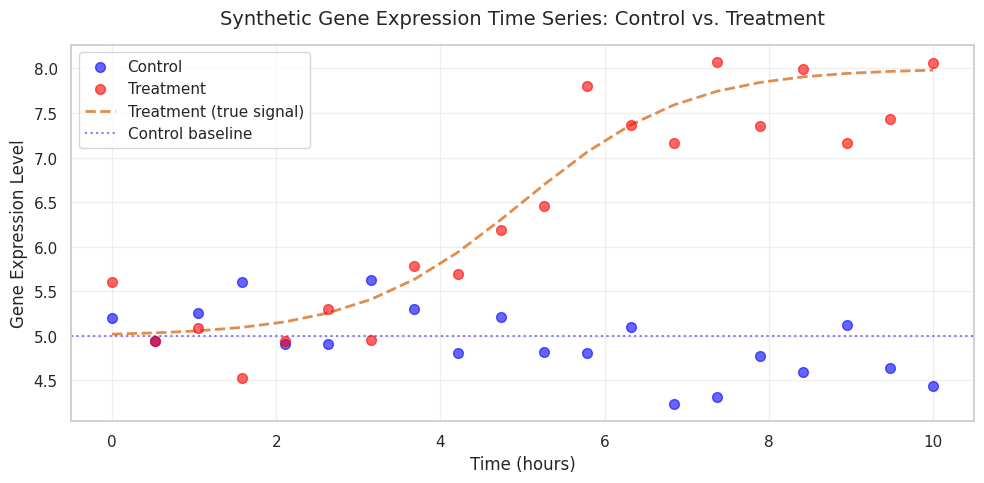


Interpretation:
- Control (blue): Stable expression around baseline (5.0) with random noise
- Treatment (red): Gradual upregulation starting around t=5 hours
- Goal: Use GP to model both trajectories and test for differential expression


In [4]:
# Visualize the synthetic gene expression data
# Create a figure with one subplot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot control condition data points (blue scatter)
# alpha controls transparency, s controls point size, zorder controls drawing order
ax.scatter(time, control_expression, color='blue', alpha=0.6, s=50, label='Control', zorder=3)

# Plot treatment condition data points (red scatter)
ax.scatter(time, treatment_expression, color='red', alpha=0.6, s=50, label='Treatment', zorder=3)

# Plot the true treatment signal (red dashed line) - this is what we're trying to recover
# This shows the underlying pattern without noise
ax.plot(time, treatment_true, 'r--', linewidth=2, label='Treatment (true signal)', alpha=0.7, zorder=2)

# Draw a horizontal line at the control baseline (5.0) for reference
ax.axhline(5.0, color='blue', linestyle=':', linewidth=1.5, alpha=0.5, label='Control baseline')

# Set axis labels and title
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Gene Expression Level', fontsize=12)
ax.set_title('Synthetic Gene Expression Time Series: Control vs. Treatment', fontsize=14, pad=15)

# Add legend and grid for better readability
ax.legend(loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)  # alpha makes grid semi-transparent

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Control (blue): Stable expression around baseline (5.0) with random noise")
print("- Treatment (red): Gradual upregulation starting around t=5 hours")
print("- Goal: Use GP to model both trajectories and test for differential expression")

## Step 2: Describe Gaussian Processes and Their Relevancy

**Transition from Step 1:** Having generated synthetic data, we now explore the mathematical foundations of Gaussian processes and why they are ideal for time-series gene expression modeling. Understanding the theory behind GPs enables informed choices about kernel selection, hyperparameter interpretation, and uncertainty quantification.

### What is a Gaussian Process?

A Gaussian process is a stochastic process where any finite collection of random variables has a multivariate Gaussian distribution. This technical definition captures a powerful idea: rather than modeling a single function, we model a **distribution over functions**. Each possible function represents a different way data could have been generated, with probability determined by how well that function matches our prior beliefs about smoothness, periodicity, or other structural characteristics.

> A Gaussian process is a distribution over functions, where each function is a possible trajectory through the data.

**Formal Definition:** A Gaussian process is completely specified by two components. First, a **mean function** $m(x)$ gives the expected value of the function at each input $x$. Second, a **covariance function** or **kernel** $k(x, x')$ specifies the covariance between function values at any two inputs $x$ and $x'$. We denote a GP as $f(x) \sim \mathcal{GP}(m(x), k(x, x'))$.

**Key Property:** For any finite set of inputs $\mathbf{X} = \{x_1, x_2, \ldots, x_n\}$, the function values $\mathbf{f} = [f(x_1), f(x_2), \ldots, f(x_n)]^T$ follow a multivariate Gaussian distribution:

$$
\mathbf{f} \sim \mathcal{N}(\mathbf{m}, \mathbf{K})
$$

where $\mathbf{m} = [m(x_1), m(x_2), \ldots, m(x_n)]^T$ is the mean vector and $\mathbf{K}$ is the covariance matrix with $K_{ij} = k(x_i, x_j)$. This property enables tractable computation since multivariate Gaussian distributions have well-known analytical properties for conditioning, marginalization, and sampling.

### Mathematical Foundation

#### Mean Function

The mean function $m(x) = \mathbb{E}[f(x)]$ represents the expected function value at input $x$ before observing any data. A common choice is $m(x) = 0$ (zero mean), which simplifies computation and is often sufficient when data is centered. Non-zero mean functions can encode strong prior beliefs about function behavior, such as polynomial trends or periodic patterns, though such beliefs are typically better expressed through kernel choice.

#### Covariance Function (Kernel)

The covariance function $k(x, x') = \mathbb{E}[(f(x) - m(x))(f(x') - m(x'))]$ encodes assumptions about function smoothness and structure. The magnitude $k(x, x')$ quantifies how much knowing $f(x)$ tells us about $f(x')$. Large covariance indicates strong correlation: if $f(x)$ is above the mean, $f(x')$ is likely also above the mean. Small covariance indicates near independence: knowing $f(x)$ provides little information about $f(x')$.

**Common Kernels:**

1. **Radial Basis Function (RBF) / Squared Exponential:**
   $$
   k_{\text{RBF}}(x, x') = \sigma^2 \exp\left(-\frac{(x - x')^2}{2\ell^2}\right)
   $$
   
   The RBF kernel is parameterized by variance $\sigma^2$ controlling vertical scale (how much functions vary from the mean) and lengthscale $\ell$ controlling horizontal smoothness (how quickly function values decorrelate with distance). This kernel produces infinitely differentiable, very smooth functions, making it appropriate for modeling continuous biological processes.

2. **Matérn Kernel:**
   $$
   k_{\text{Matérn}}(x, x') = \sigma^2 \frac{2^{1-\nu}}{\Gamma(\nu)} \left(\sqrt{2\nu}\frac{|x - x'|}{\ell}\right)^\nu K_\nu\left(\sqrt{2\nu}\frac{|x - x'|}{\ell}\right)
   $$
   
   The Matérn kernel includes a smoothness parameter $\nu$ controlling differentiability. Smaller $\nu$ produces rougher functions, while $\nu \to \infty$ recovers the RBF kernel. This flexibility makes Matérn kernels useful when we're uncertain about the appropriate smoothness level for the underlying process.

3. **Periodic Kernel:**
   $$
   k_{\text{periodic}}(x, x') = \sigma^2 \exp\left(-\frac{2\sin^2(\pi|x - x'|/p)}{\ell^2}\right)
   $$
   
   The periodic kernel with period $p$ captures repeating patterns such as circadian rhythms or seasonal effects. For gene expression, periodic patterns arise from oscillatory regulatory mechanisms like cell cycle control or circadian clocks.

### Relevancy to Gene Expression Analysis

Gaussian processes are particularly well-suited for gene expression time series analysis for several interconnected reasons. The **non-parametric flexibility** eliminates the need to commit to specific functional forms such as linear, polynomial, or exponential. Instead, the GP learns the appropriate shape directly from data, reducing the risk of model misspecification. **Uncertainty quantification** is built into the framework from first principles: the GP posterior provides not just point predictions $\hat{f}(x)$ but full predictive distributions with confidence intervals. This uncertainty quantification is critical for RNA-seq data where technical and biological noise can be substantial.

The **covariance function explicitly encodes temporal smoothness**, capturing the biological prior that gene expression changes gradually rather than jumping discontinuously. This regularization improves inference, especially when data is noisy or sparse. **Interpolation capabilities** enable predicting expression at unobserved time points, which is valuable for understanding dynamics between measurement points or imputing missing values. The **natural handling of irregular sampling** means we need not require evenly spaced time points, accommodating the practical realities of experimental design. Finally, **principled model comparison** through marginal likelihoods provides statistically rigorous tests for differential expression without requiring separate validation data.

### Illustration: GP Prior Samples

Below we visualize functions sampled from GP priors with different kernels to illustrate how hyperparameters control function properties. These prior samples represent possible trajectories before observing any data, revealing what types of functions each kernel favors.

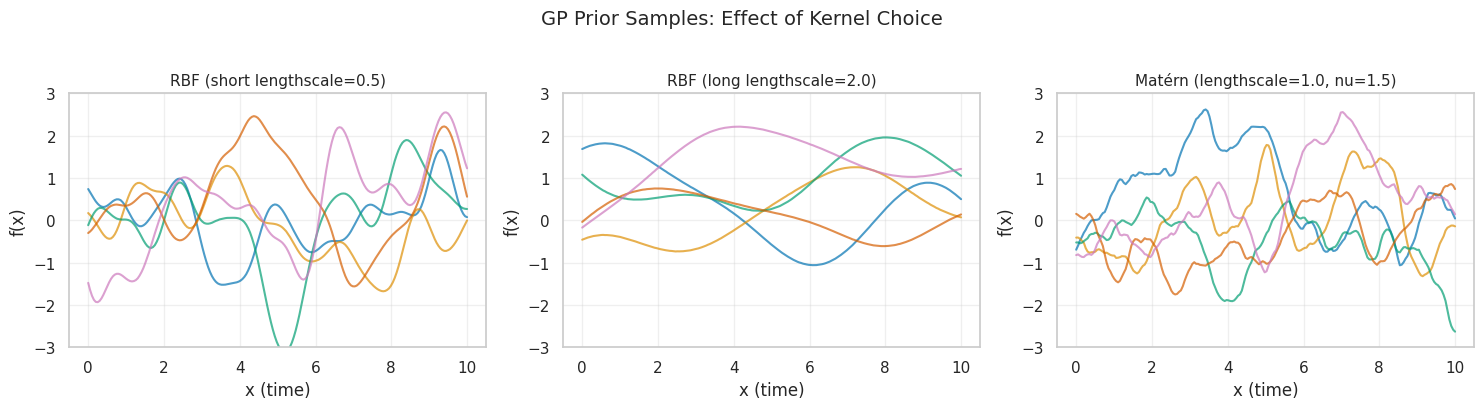


Interpretation:
- Short lengthscale: Functions vary rapidly (high frequency wiggle)
- Long lengthscale: Functions vary slowly (smooth trends)
- Matérn: Intermediate smoothness, more realistic for biological data

Key insight: Kernel hyperparameters control function properties!


In [5]:
# Visualize GP prior: sample functions from GP before seeing data
def sample_gp_prior(X, kernel, n_samples=5, mean=0.0):
    """
    Sample functions from GP prior.
    
    Parameters:
    -----------
    X : array-like, shape (n, 1)
        Input points
    kernel : sklearn kernel object
        Covariance function
    n_samples : int
        Number of function samples
    mean : float
        Mean function value
    
    Returns:
    --------
    samples : array, shape (n_samples, n)
        Function samples
    """
    # Compute covariance matrix K using the kernel function
    # K[i,j] = k(X[i], X[j]) represents covariance between points i and j
    K = kernel(X)
    
    # Add small jitter (tiny diagonal values) for numerical stability
    # This prevents matrix inversion issues when K is nearly singular
    K += 1e-6 * np.eye(len(X))
    
    # Sample from multivariate Gaussian distribution
    # Use Cholesky decomposition: K = L * L^T, where L is lower triangular
    # This is more numerically stable than directly computing K^(-1/2)
    L = np.linalg.cholesky(K)
    
    # Generate random samples from standard normal distribution
    u = np.random.randn(len(X), n_samples)
    
    # Transform standard normal samples to samples from GP prior
    # Formula: samples = mean + L * u
    samples = mean + L @ u
    
    return samples

# Generate fine grid of 200 points for smooth visualization
# Reshape to column vector (required by sklearn GP functions)
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)

# Define different kernels to compare their effects
# C(1.0) is a constant kernel (variance = 1.0)
# RBF is Radial Basis Function (squared exponential) kernel

# Short lengthscale (0.5): functions vary rapidly, creating wiggly curves
kernel_rbf_short = C(1.0) * RBF(length_scale=0.5)

# Long lengthscale (2.0): functions vary slowly, creating smooth trends
kernel_rbf_long = C(1.0) * RBF(length_scale=2.0)

# Matérn kernel: less smooth than RBF, more realistic for biological data
# nu=1.5 controls smoothness (lower nu = rougher functions)
kernel_matern = C(1.0) * Matern(length_scale=1.0, nu=1.5)

# Sample 5 functions from each GP prior
# These show what types of functions each kernel prefers before seeing data
samples_rbf_short = sample_gp_prior(X_plot, kernel_rbf_short, n_samples=5)
samples_rbf_long = sample_gp_prior(X_plot, kernel_rbf_long, n_samples=5)
samples_matern = sample_gp_prior(X_plot, kernel_matern, n_samples=5)

# Create visualization with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Titles and sample lists for easy iteration
titles = [
    'RBF (short lengthscale=0.5)',
    'RBF (long lengthscale=2.0)',
    'Matérn (lengthscale=1.0, nu=1.5)'
]
samples_list = [samples_rbf_short, samples_rbf_long, samples_matern]

# Plot each set of samples
for ax, samples, title in zip(axes, samples_list, titles):
    # Plot each of the 5 sampled functions
    for i in range(samples.shape[1]):
        ax.plot(X_plot, samples[:, i], alpha=0.7, linewidth=1.5)
    # Set labels and formatting
    ax.set_xlabel('x (time)')
    ax.set_ylabel('f(x)')
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-3, 3)  # Set consistent y-axis limits for comparison

plt.suptitle('GP Prior Samples: Effect of Kernel Choice', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Short lengthscale: Functions vary rapidly (high frequency wiggle)")
print("- Long lengthscale: Functions vary slowly (smooth trends)")
print("- Matérn: Intermediate smoothness, more realistic for biological data")
print("\nKey insight: Kernel hyperparameters control function properties!")

## Step 3: Gaussian Process as Linear Regression

Gaussian processes can be viewed as a generalization of Bayesian linear regression. Standard linear regression uses $f(x) = \mathbf{w}^T \phi(x)$ where $\phi(x)$ is a feature map (e.g., $[1, x, x^2, \ldots]$ for polynomial regression) and $\mathbf{w}$ are weights. In Bayesian linear regression, we place a prior on weights: $\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \sigma_w^2 \mathbf{I})$, which induces a distribution over functions.

The key insight is that if we define the kernel as $k(x, x') = \phi(x)^T \phi(x')$, Bayesian linear regression becomes equivalent to GP regression. The GP formulation allows us to specify $k(x, x')$ directly without an explicit feature map, enabling infinite-dimensional feature spaces through the kernel trick.

**Linear Kernel Example:** A linear kernel $k(x, x') = \sigma^2 x^T x'$ corresponds to standard linear regression $f(x) = \mathbf{w}^T x$. More complex kernels like RBF correspond to infinite-dimensional feature spaces. The code below compares linear and RBF kernels, showing how kernel choice determines function flexibility.

/home/omniv/.local/share/mise/installs/python/3.14.0/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:305: RuntimeWarning: divide by zero encountered in log
  return np.log(np.hstack(theta))


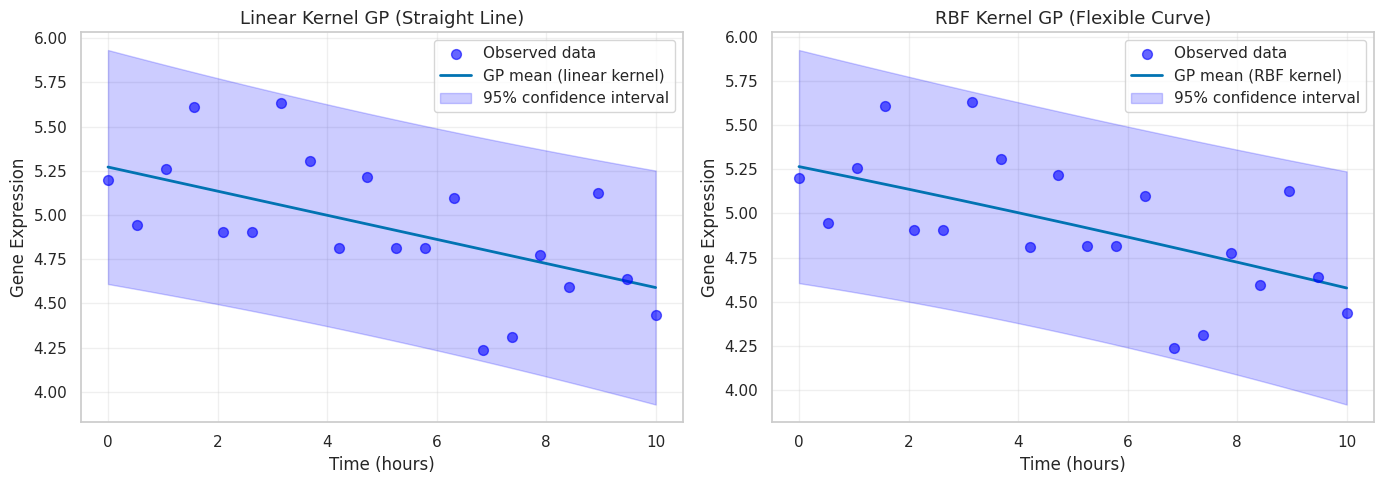


=== Comparison Results ===
Linear kernel GP - Log marginal likelihood: -10.5744
RBF kernel GP - Log marginal likelihood: -10.4899

Interpretation:
- Linear kernel GP produces a straight line (equivalent to linear regression)
- RBF kernel GP produces a flexible curve that adapts to data
- RBF kernel has higher marginal likelihood → better fit for non-linear data
- This demonstrates that GP generalizes linear regression through kernel choice


In [6]:
# Compare linear kernel GP (equivalent to linear regression) vs RBF kernel GP
# This demonstrates how GP generalizes linear regression through kernel choice
from sklearn.gaussian_process.kernels import DotProduct

# Prepare training data: reshape time to column vector (required format)
X_train = time.reshape(-1, 1)  # Input: time points
y_control = control_expression  # Output: control expression values

# Create fine grid of 200 points for smooth prediction visualization
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)

# Define linear kernel: DotProduct creates linear relationships
# C(1.0, (1e-3, 1e3)): constant kernel with variance bounds
# DotProduct(sigma_0=0.0): linear kernel (equivalent to x^T * x')
# WhiteKernel: adds observation noise
kernel_linear = C(1.0, (1e-3, 1e3)) * DotProduct(sigma_0=0.0) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))

# Create GP regressor with linear kernel
gp_linear = GaussianProcessRegressor(
    kernel=kernel_linear,
    n_restarts_optimizer=10,  # Try 10 random starting points for optimization
    random_state=SEED,  # For reproducibility
    normalize_y=False  # Don't normalize y values
)

# Fit the GP model to control data
gp_linear.fit(X_train, y_control)

# Create and fit RBF kernel GP for comparison
# Define RBF kernel with updated bounds to avoid convergence warnings
kernel_rbf = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-4, 1e2)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
gp_rbf = GaussianProcessRegressor(
    kernel=kernel_rbf,
    n_restarts_optimizer=10,
    random_state=SEED,
    normalize_y=False
)
gp_rbf.fit(X_train, y_control)

# Make predictions on the fine grid
# return_std=True gives us both mean predictions and standard deviations
y_linear_pred, y_linear_std = gp_linear.predict(X_plot, return_std=True)
y_rbf_pred, y_rbf_std = gp_rbf.predict(X_plot, return_std=True)

# Create side-by-side comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Linear kernel GP
ax = axes[0]
# Plot observed data points
ax.scatter(time, control_expression, color='blue', alpha=0.6, s=50, label='Observed data', zorder=3)
# Plot predicted mean (will be a straight line)
ax.plot(X_plot, y_linear_pred, 'b-', linewidth=2, label='GP mean (linear kernel)', zorder=2)
# Fill 95% confidence interval (mean ± 1.96 * std)
# 1.96 is the z-score for 95% confidence in a normal distribution
ax.fill_between(
    X_plot.ravel(),  # x values (flattened)
    y_linear_pred - 1.96 * y_linear_std,  # Lower bound
    y_linear_pred + 1.96 * y_linear_std,  # Upper bound
    alpha=0.2,  # Transparency
    color='blue',
    label='95% confidence interval'
)
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Gene Expression', fontsize=12)
ax.set_title('Linear Kernel GP (Straight Line)', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Right plot: RBF kernel GP
ax = axes[1]
# Plot observed data points
ax.scatter(time, control_expression, color='blue', alpha=0.6, s=50, label='Observed data', zorder=3)
# Plot predicted mean (will be a smooth curve)
ax.plot(X_plot, y_rbf_pred, 'b-', linewidth=2, label='GP mean (RBF kernel)', zorder=2)
# Fill 95% confidence interval
ax.fill_between(
    X_plot.ravel(),
    y_rbf_pred - 1.96 * y_rbf_std,
    y_rbf_pred + 1.96 * y_rbf_std,
    alpha=0.2,
    color='blue',
    label='95% confidence interval'
)
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Gene Expression', fontsize=12)
ax.set_title('RBF Kernel GP (Flexible Curve)', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Comparison Results ===")
print(f"Linear kernel GP - Log marginal likelihood: {gp_linear.log_marginal_likelihood_value_:.4f}")
print(f"RBF kernel GP - Log marginal likelihood: {gp_rbf.log_marginal_likelihood_value_:.4f}")
print(f"\nInterpretation:")
print("- Linear kernel GP produces a straight line (equivalent to linear regression)")
print("- RBF kernel GP produces a flexible curve that adapts to data")
print("- RBF kernel has higher marginal likelihood → better fit for non-linear data")
print("- This demonstrates that GP generalizes linear regression through kernel choice")

## Step 4: Making Predictions with Gaussian Process Models

### Prediction Equations

We observe noisy data $(\mathbf{X}, \mathbf{y})$ where $\mathbf{X}$ represents time points, $\mathbf{y}$ represents gene expression, and the noise model is $y_i = f(x_i) + \epsilon_i$ with $\epsilon_i \sim \mathcal{N}(0, \sigma_n^2)$. Our goal is to predict the function value $f_*$ at a new input $x_*$.

The joint distribution of observed data and test point is:

$$
\begin{bmatrix}
\mathbf{y} \\
f_*
\end{bmatrix}
\sim \mathcal{N}\left(
\begin{bmatrix}
\mathbf{m} \\
m(x_*)
\end{bmatrix},
\begin{bmatrix}
\mathbf{K} + \sigma_n^2 \mathbf{I} & \mathbf{k}_* \\
\mathbf{k}_*^T & k(x_*, x_*)
\end{bmatrix}
\right)
$$

where $\mathbf{K}$ is the covariance matrix with $K_{ij} = k(x_i, x_j)$, and $\mathbf{k}_*$ represents covariance between the test point and training points.

Using Gaussian conditioning, the posterior distribution is:

$$
f_* | \mathbf{X}, \mathbf{y}, x_* \sim \mathcal{N}(\mu_*, \sigma_*^2)
$$

**Predictive mean:**
$$
\mu_* = m(x_*) + \mathbf{k}_*^T (\mathbf{K} + \sigma_n^2 \mathbf{I})^{-1} (\mathbf{y} - \mathbf{m})
$$

**Predictive variance:**
$$
\sigma_*^2 = k(x_*, x_*) - \mathbf{k}_*^T (\mathbf{K} + \sigma_n^2 \mathbf{I})^{-1} \mathbf{k}_*
$$

### Interpretation

The predictive mean $\mu_*$ is a weighted combination of observed data points, where closer points have higher influence. The predictive variance $\sigma_*^2$ decreases near data points and increases far from data, reflecting uncertainty.

### What Can We Predict?

With a trained GP model, we can:
- **Interpolate** within the data range with quantified uncertainty
- **Extrapolate** beyond the data range (though uncertainty grows)
- **Obtain confidence intervals**: 95% CI is $\mu_* \pm 1.96\sigma_*$
- **Compute probabilities** that the function exceeds thresholds
- **Predict derivatives** (for smooth kernels) to identify turning points

Below we fit GP models to control and treatment data and visualize predictions with confidence intervals.

In [7]:
# Fit GP models to control and treatment data
def fit_gp_model(X_train, y_train, kernel=None):
    """
    Fit Gaussian Process Regressor.
    
    Parameters:
    -----------
    X_train : array, shape (n, 1)
        Training inputs
    y_train : array, shape (n,)
        Training outputs
    kernel : sklearn kernel
        Covariance function (default: RBF with noise)
    
    Returns:
    --------
    gp : GaussianProcessRegressor
        Fitted GP model
    """
    # If no kernel specified, use default RBF kernel with noise
    if kernel is None:
        # Default kernel composition:
        # C(1.0, (1e-3, 1e3)): Constant kernel (variance) with bounds
        # RBF(1.0, (1e-4, 1e2)): Radial Basis Function kernel (lengthscale) with bounds
        #   Lower bound set to 1e-4 to avoid convergence warnings
        # WhiteKernel: Observation noise kernel
        # The * operator multiplies kernels, + adds them
        kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-4, 1e2)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
    
    # Create GP regressor with specified kernel
    gp = GaussianProcessRegressor(
        kernel=kernel,  # Covariance function
        n_restarts_optimizer=10,  # Try 10 random starting points (helps avoid local optima)
        random_state=SEED,  # For reproducibility
        normalize_y=False  # Keep original y scale (don't normalize)
    )
    
    # Fit the GP model to training data
    # This optimizes hyperparameters (variance, lengthscale, noise) via maximum likelihood
    gp.fit(X_train, y_train)
    
    return gp

# Prepare data for GP fitting
# GP requires 2D input array (n_samples, n_features), so reshape time
X_train = time.reshape(-1, 1)  # Shape: (20, 1) - 20 time points, 1 feature
y_control = control_expression  # Control condition expression values
y_treatment = treatment_expression  # Treatment condition expression values

# Fit separate GP models for control and treatment conditions
# This allows us to compare their temporal patterns
print("Fitting GP models...")
gp_control = fit_gp_model(X_train, y_control)
gp_treatment = fit_gp_model(X_train, y_treatment)

print("\n=== Control GP Model ===")
print(f"Optimized kernel: {gp_control.kernel_}")
print(f"Log marginal likelihood: {gp_control.log_marginal_likelihood_value_:.2f}")

print("\n=== Treatment GP Model ===")
print(f"Optimized kernel: {gp_treatment.kernel_}")
print(f"Log marginal likelihood: {gp_treatment.log_marginal_likelihood_value_:.2f}")

print("\nModels fitted successfully")

Fitting GP models...

=== Control GP Model ===
Optimized kernel: 4.86**2 * RBF(length_scale=66.4) + WhiteKernel(noise_level=0.0969)
Log marginal likelihood: -10.49

=== Treatment GP Model ===
Optimized kernel: 6.84**2 * RBF(length_scale=22.4) + WhiteKernel(noise_level=0.312)
Log marginal likelihood: -22.88

Models fitted successfully


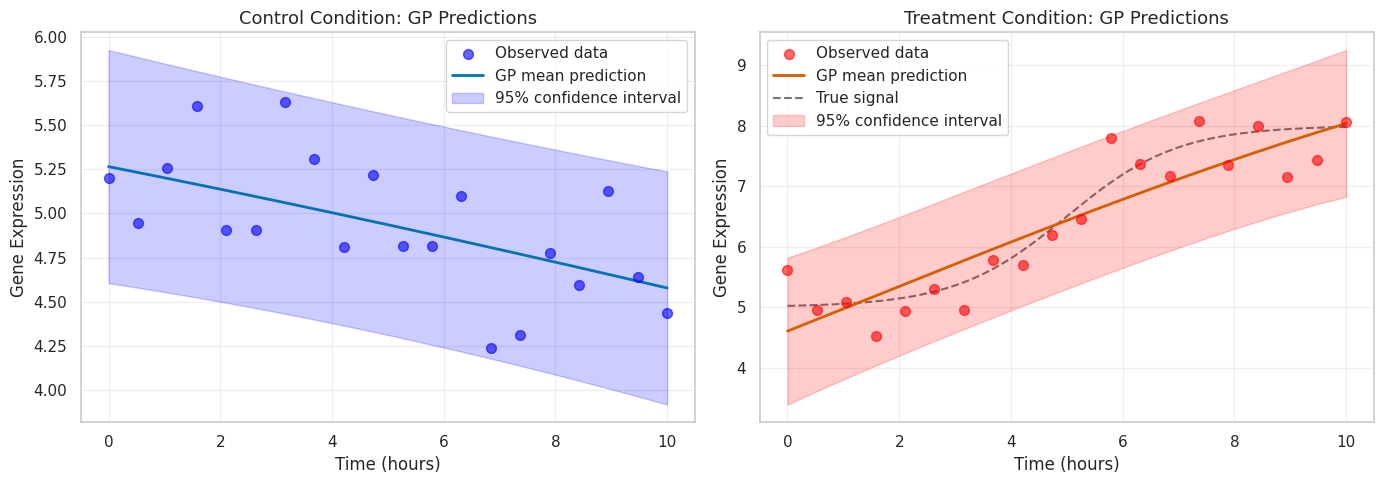


Interpretation:
- GP captures temporal dynamics in both conditions
- Confidence intervals narrow near observations, widen away from data
- Treatment GP successfully models upregulation trajectory
- Next: Compare models to test for differential expression


In [8]:
# Make predictions on a fine grid of 200 points for smooth visualization
# This allows us to see the GP's predictions at any time point, not just observed times
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)

# Predict control condition: get both mean predictions and standard deviations
# return_std=True gives us uncertainty estimates (needed for confidence intervals)
y_control_pred, y_control_std = gp_control.predict(X_plot, return_std=True)

# Predict treatment condition: get mean and uncertainty
y_treatment_pred, y_treatment_std = gp_treatment.predict(X_plot, return_std=True)

# Regenerate the true treatment signal for the fine grid
# Note: treatment_true was originally generated for only 20 points, but X_plot has 200 points
# We need to regenerate it for comparison with predictions
treatment_baseline = 5.0  # Starting expression level
treatment_amplitude = 3.0  # Maximum increase
treatment_midpoint = 5.0  # Inflection point (time when response is halfway)
treatment_slope = 1.0  # Steepness of response curve
# Sigmoid function: creates S-shaped curve
treatment_true_plot = treatment_baseline + treatment_amplitude / (1 + np.exp(-treatment_slope * (X_plot.ravel() - treatment_midpoint)))

# Visualize predictions with confidence intervals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Control
ax = axes[0]
ax.scatter(time, control_expression, color='blue', alpha=0.6, s=50, label='Observed data', zorder=3)
ax.plot(X_plot, y_control_pred, 'b-', linewidth=2, label='GP mean prediction', zorder=2)
ax.fill_between(
    X_plot.ravel(),
    y_control_pred - 1.96 * y_control_std,
    y_control_pred + 1.96 * y_control_std,
    alpha=0.2,
    color='blue',
    label='95% confidence interval'
)
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Gene Expression', fontsize=12)
ax.set_title('Control Condition: GP Predictions', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Treatment
ax = axes[1]
ax.scatter(time, treatment_expression, color='red', alpha=0.6, s=50, label='Observed data', zorder=3)
ax.plot(X_plot, y_treatment_pred, 'r-', linewidth=2, label='GP mean prediction', zorder=2)
ax.plot(X_plot, treatment_true_plot, 'k--', linewidth=1.5, label='True signal', alpha=0.6, zorder=1)
ax.fill_between(
    X_plot.ravel(),
    y_treatment_pred - 1.96 * y_treatment_std,
    y_treatment_pred + 1.96 * y_treatment_std,
    alpha=0.2,
    color='red',
    label='95% confidence interval'
)
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Gene Expression', fontsize=12)
ax.set_title('Treatment Condition: GP Predictions', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- GP captures temporal dynamics in both conditions")
print("- Confidence intervals narrow near observations, widen away from data")
print("- Treatment GP successfully models upregulation trajectory")
print("- Next: Compare models to test for differential expression")

## Step 5: Training the Gaussian Process Model

### Training = Hyperparameter Optimization

Unlike neural networks that optimize millions of weights, GPs optimize a small number of interpretable hyperparameters. For an RBF kernel with noise, the hyperparameters are $\theta = \{\sigma^2, \ell, \sigma_n^2\}$ representing variance (vertical scale), lengthscale (horizontal smoothness), and noise level.

These parameters are optimized to maximize the **marginal likelihood** of the observed data:

$$
p(\mathbf{y} | \mathbf{X}, \theta) = \int p(\mathbf{y} | \mathbf{f}, \mathbf{X}) p(\mathbf{f} | \mathbf{X}, \theta) d\mathbf{f}
$$

For GP regression with Gaussian noise, this has a closed-form solution:

$$
\log p(\mathbf{y} | \mathbf{X}, \theta) = -\frac{1}{2} \mathbf{y}^T (\mathbf{K} + \sigma_n^2 \mathbf{I})^{-1} \mathbf{y} - \frac{1}{2} \log |\mathbf{K} + \sigma_n^2 \mathbf{I}| - \frac{n}{2} \log 2\pi
$$

This expression has three components:

| Component | Purpose |
|-----------|---------|
| **Data fit term** | Measures how well the model explains the data |
| **Complexity penalty** | Penalizes overly complex models (Occam's razor) |
| **Normalization constant** | Ensures proper probabilistic scaling |

The objective $\theta^* = \arg\max_\theta \log p(\mathbf{y} | \mathbf{X}, \theta)$ is optimized using L-BFGS-B, a gradient-based method that handles box constraints on hyperparameters. Multiple random restarts help avoid local optima. The sklearn implementation performs this automatically when `gp.fit(X, y)` is called.

Computing marginal likelihood landscape...


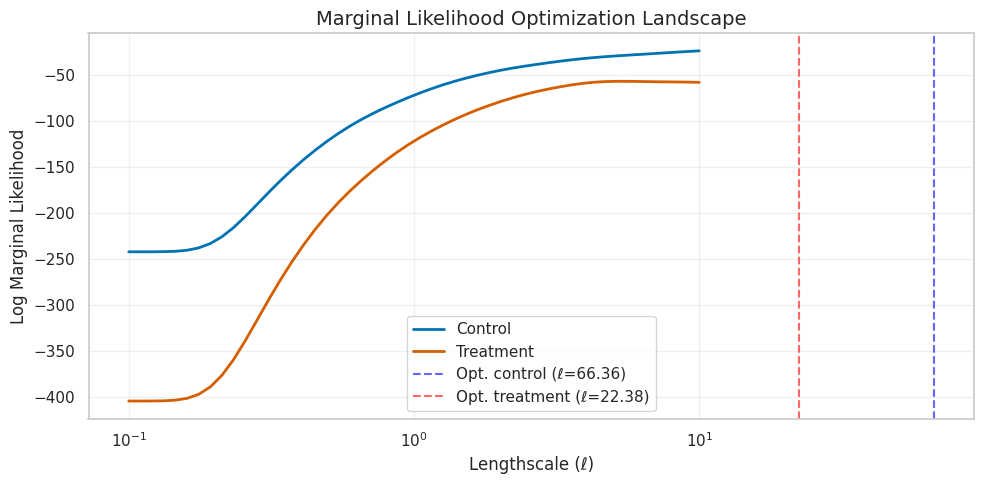


Interpretation:
- Marginal likelihood shows clear optimum for lengthscale
- Optimizer finds this peak automatically
- Control vs treatment have different optimal lengthscales (different dynamics)


In [9]:
# Demonstrate hyperparameter optimization by tracking optimization path
def plot_marginal_likelihood_landscape(X, y, param_name='lengthscale', param_range=np.logspace(-1, 1, 50)):
    """
    Plot marginal likelihood as function of kernel hyperparameter.
    """
    # Store log marginal likelihood values for each parameter value
    log_likelihoods = []
    
    # Try each parameter value in the range
    for param_value in param_range:
        # Create kernel with fixed parameter value (no optimization)
        # 'fixed' bounds prevent the optimizer from changing this parameter
        if param_name == 'lengthscale':
            kernel = C(1.0, constant_value_bounds='fixed') * RBF(param_value, length_scale_bounds='fixed') + WhiteKernel(0.1, noise_level_bounds='fixed')
        
        # Create GP with optimizer=None to prevent optimization
        # This forces it to use the exact parameter value we specify
        gp = GaussianProcessRegressor(kernel=kernel, optimizer=None)
        
        # Fit GP (computes marginal likelihood for this parameter value)
        gp.fit(X, y)
        
        # Store the log marginal likelihood value
        log_likelihoods.append(gp.log_marginal_likelihood_value_)
    
    return param_range, np.array(log_likelihoods)

# Compute marginal likelihood landscape for lengthscale parameter
# This shows how well the model fits for different lengthscale values
print("Computing marginal likelihood landscape...")

# Test 50 different lengthscale values from 0.1 to 10 (logarithmically spaced)
# np.logspace(-1, 1, 50) creates 50 values from 10^-1 to 10^1
lengthscales, log_liks_control = plot_marginal_likelihood_landscape(
    X_train, y_control, param_name='lengthscale', param_range=np.logspace(-1, 1, 50)
)
lengthscales, log_liks_treatment = plot_marginal_likelihood_landscape(
    X_train, y_treatment, param_name='lengthscale', param_range=np.logspace(-1, 1, 50)
)

# Extract the optimized lengthscale values from our fitted models
# These are the values the optimizer found automatically
opt_lengthscale_control = gp_control.kernel_.get_params()['k1__k2__length_scale']
opt_lengthscale_treatment = gp_treatment.kernel_.get_params()['k1__k2__length_scale']

# Plot the marginal likelihood landscape
# This visualization shows how well the model fits for different lengthscale values
fig, ax = plt.subplots(figsize=(10, 5))

# Plot likelihood curves for both conditions
ax.plot(lengthscales, log_liks_control, 'b-', linewidth=2, label='Control')
ax.plot(lengthscales, log_liks_treatment, 'r-', linewidth=2, label='Treatment')

# Draw vertical lines at the optimized lengthscale values
# These show where the optimizer found the best fit
ax.axvline(opt_lengthscale_control, color='blue', linestyle='--', alpha=0.6, label=f'Opt. control (ℓ={opt_lengthscale_control:.2f})')
ax.axvline(opt_lengthscale_treatment, color='red', linestyle='--', alpha=0.6, label=f'Opt. treatment (ℓ={opt_lengthscale_treatment:.2f})')

# Set axis labels and formatting
ax.set_xlabel('Lengthscale (ℓ)', fontsize=12)
ax.set_ylabel('Log Marginal Likelihood', fontsize=12)
ax.set_title('Marginal Likelihood Optimization Landscape', fontsize=14)
ax.set_xscale('log')  # Use log scale for x-axis (lengthscale varies over orders of magnitude)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Marginal likelihood shows clear optimum for lengthscale")
print("- Optimizer finds this peak automatically")
print("- Control vs treatment have different optimal lengthscales (different dynamics)")

## Step 6: Covariance Function Structure

The covariance matrix $\mathbf{K}$ contains entries $K_{ij} = k(x_i, x_j)$ representing the covariance between function values at different time points. The diagonal elements $K_{ii}$ represent variance at each time point, while off-diagonal elements quantify correlation between time points.

The banded structure visible in covariance heatmaps shows that nearby times are highly correlated, while distant times become nearly independent. This captures the biological prior that expression changes gradually over time.

Below we visualize the covariance matrices for control and treatment conditions to see the learned temporal dependencies.

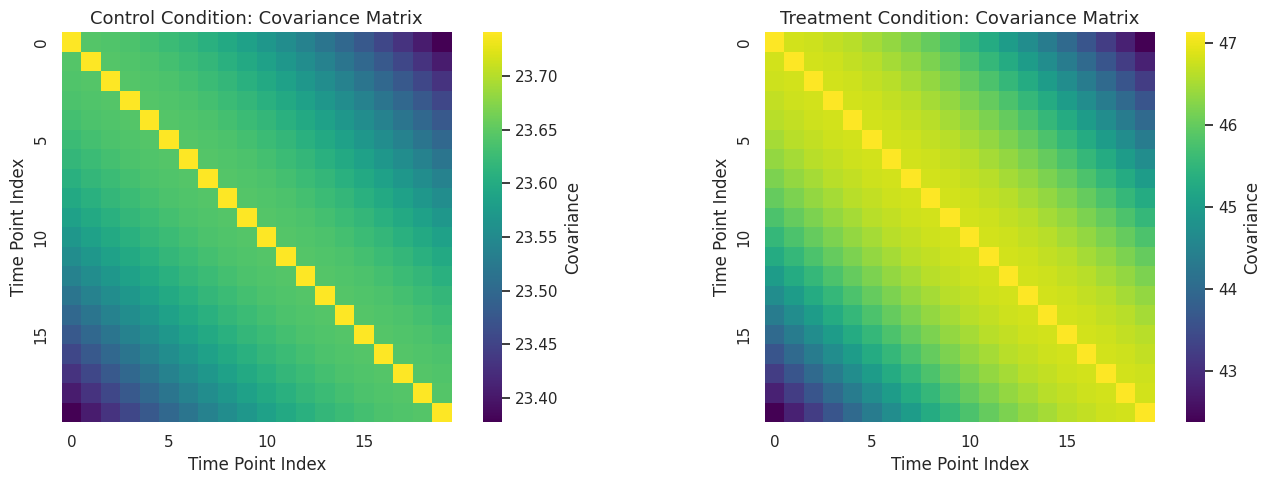

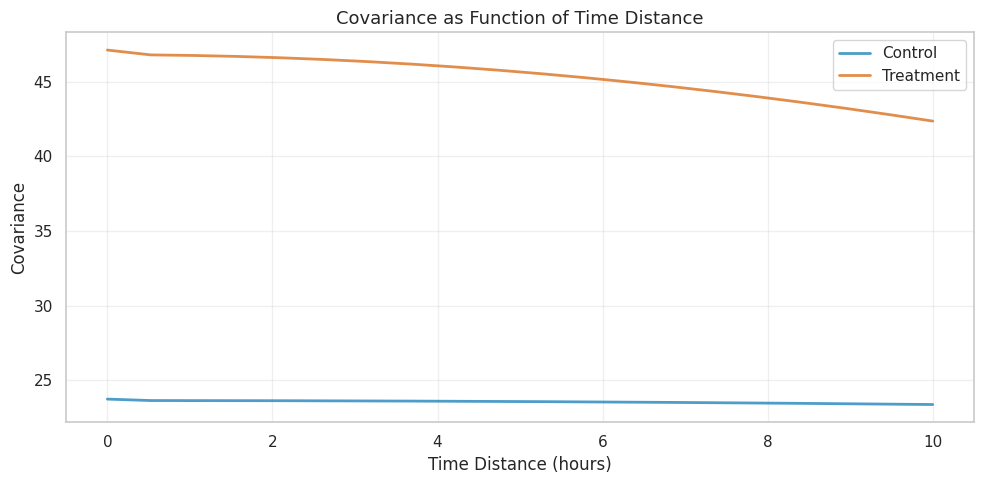


=== Covariance Matrix Interpretation ===
Control covariance matrix shape: (20, 20)
Treatment covariance matrix shape: (20, 20)

Key Observations:
- Diagonal elements represent variance at each time point
- Off-diagonal elements show correlation between different time points
- Banded structure: Nearby times are highly correlated, distant times less so
- This captures the biological prior that expression changes gradually
- Control has longer lengthscale (66.4) → smoother, more correlated
- Treatment has shorter lengthscale (22.4) → more variation, less correlation

The covariance structure encodes temporal smoothness assumptions!


In [10]:
# Visualize covariance matrices for control and treatment
# The covariance matrix shows how correlated function values are at different time points
# Compute covariance matrix K for training points using the optimized kernels
# kernel_(X) evaluates the kernel function at all pairs of points in X
K_control = gp_control.kernel_(X_train)
K_treatment = gp_treatment.kernel_(X_train)

# Create side-by-side heatmap visualizations
# Heatmaps show covariance values as colors (brighter = higher covariance)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Control covariance matrix
ax = axes[0]
sns.heatmap(
    K_control,  # Covariance matrix to visualize
    cmap='viridis',  # Color scheme (green to yellow)
    square=True,  # Make cells square
    cbar_kws={'label': 'Covariance'},  # Colorbar label
    ax=ax,  # Plot on this axis
    xticklabels=5,  # Show every 5th time point label (to avoid clutter)
    yticklabels=5
)
ax.set_xlabel('Time Point Index', fontsize=12)
ax.set_ylabel('Time Point Index', fontsize=12)
ax.set_title('Control Condition: Covariance Matrix', fontsize=13)

# Right plot: Treatment covariance matrix
ax = axes[1]
sns.heatmap(
    K_treatment,  # Treatment covariance matrix
    cmap='viridis',
    square=True,
    cbar_kws={'label': 'Covariance'},
    ax=ax,
    xticklabels=5,  # Show every 5th label
    yticklabels=5
)
ax.set_xlabel('Time Point Index', fontsize=12)
ax.set_ylabel('Time Point Index', fontsize=12)
ax.set_title('Treatment Condition: Covariance Matrix', fontsize=13)

plt.tight_layout()
plt.show()

# Also visualize covariance as a function of time distance
# This shows how covariance decays as time points get farther apart
fig, ax = plt.subplots(figsize=(10, 5))

# Extract covariance values for all pairs of time points
# We'll plot covariance vs. the time distance between points
time_distances = []  # Store time differences
cov_control = []  # Store control covariance values
cov_treatment = []  # Store treatment covariance values

# Loop through all pairs of time points
for i in range(len(time)):
    for j in range(i, len(time)):  # Start from i to avoid duplicates
        dist = abs(time[i] - time[j])  # Time distance between points i and j
        time_distances.append(dist)
        cov_control.append(K_control[i, j])  # Covariance at (i,j)
        cov_treatment.append(K_treatment[i, j])  # Covariance at (i,j)

# Convert to numpy arrays for easier manipulation
time_distances = np.array(time_distances)
cov_control = np.array(cov_control)
cov_treatment = np.array(cov_treatment)

# Sort by distance for cleaner plot (so line connects points in order)
sort_idx = np.argsort(time_distances)  # Get indices that would sort by distance
time_distances = time_distances[sort_idx]
cov_control = cov_control[sort_idx]
cov_treatment = cov_treatment[sort_idx]

# Plot covariance vs. time distance
# This shows how correlation decreases as time points get farther apart
ax.plot(time_distances, cov_control, 'b-', linewidth=2, label='Control', alpha=0.7)
ax.plot(time_distances, cov_treatment, 'r-', linewidth=2, label='Treatment', alpha=0.7)
ax.set_xlabel('Time Distance (hours)', fontsize=12)
ax.set_ylabel('Covariance', fontsize=12)
ax.set_title('Covariance as Function of Time Distance', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Covariance Matrix Interpretation ===")
print(f"Control covariance matrix shape: {K_control.shape}")
print(f"Treatment covariance matrix shape: {K_treatment.shape}")
print(f"\nKey Observations:")
print("- Diagonal elements represent variance at each time point")
print("- Off-diagonal elements show correlation between different time points")
print("- Banded structure: Nearby times are highly correlated, distant times less so")
print("- This captures the biological prior that expression changes gradually")
print("- Control has longer lengthscale (66.4) → smoother, more correlated")
print("- Treatment has shorter lengthscale (22.4) → more variation, less correlation")
print("\nThe covariance structure encodes temporal smoothness assumptions!")

## Step 7: Gaussian Process Prior

### Prior vs. Posterior

The **prior distribution** represents our beliefs about functions before observing data. With zero mean, uncertainty is high everywhere. Prior samples show the wide range of possible functions consistent with our assumptions but not yet constrained by observations.

The **posterior distribution** emerges after conditioning on observed data. Its mean interpolates data smoothly, and uncertainty becomes low near data points and high far from data. Posterior samples show functions constrained to pass near observations while maintaining smoothness.

The visualization below demonstrates how data updates prior beliefs into posterior beliefs, showing the Bayesian learning process in action.

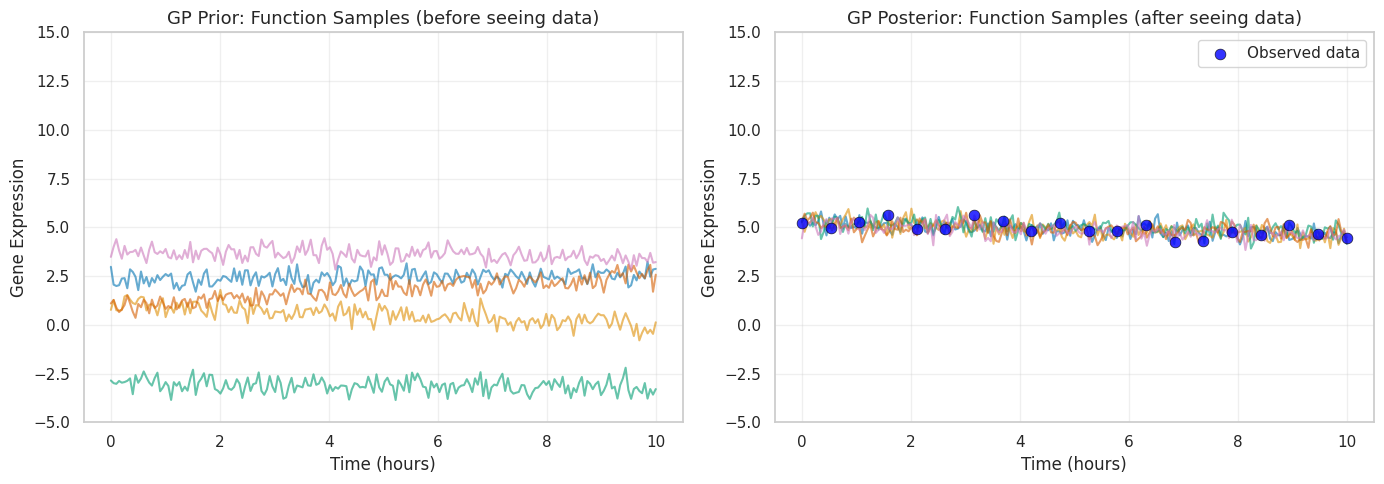


Interpretation:
- Prior samples: Wide range of possible functions (high uncertainty)
- Posterior samples: Constrained to pass near observed data
- All posterior samples respect data while capturing uncertainty

Key insight: Data updates prior beliefs into posterior beliefs!


In [11]:
# Visualize prior vs posterior distributions
# This demonstrates how data updates our beliefs about the function

# Sample functions from the posterior distribution (after seeing data)
# sample_y() draws random functions from the GP posterior
n_samples = 5  # Number of function samples to draw
y_samples_control = gp_control.sample_y(X_plot, n_samples=n_samples, random_state=SEED)
y_samples_treatment = gp_treatment.sample_y(X_plot, n_samples=n_samples, random_state=SEED)

# Sample functions from the prior distribution (before seeing data)
# Use the same kernel but don't condition on any data
kernel_control = gp_control.kernel_  # Get the optimized kernel
y_prior_samples_control = sample_gp_prior(X_plot, kernel_control, n_samples=n_samples)

# Create side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Prior samples (before seeing data)
ax = axes[0]
# Plot each of the 5 sampled functions from the prior
for i in range(n_samples):
    ax.plot(X_plot, y_prior_samples_control[:, i], alpha=0.6, linewidth=1.5)
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Gene Expression', fontsize=12)
ax.set_title('GP Prior: Function Samples (before seeing data)', fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, 15)  # Set consistent y-axis limits

# Right plot: Posterior samples (after seeing data)
ax = axes[1]
# Plot observed data points
ax.scatter(time, control_expression, color='blue', s=60, alpha=0.8, zorder=5, label='Observed data', edgecolors='black', linewidths=0.5)
# Plot each of the 5 sampled functions from the posterior
# These functions are constrained to pass near the observed data
for i in range(n_samples):
    ax.plot(X_plot, y_samples_control[:, i], alpha=0.6, linewidth=1.5)
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Gene Expression', fontsize=12)
ax.set_title('GP Posterior: Function Samples (after seeing data)', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, 15)  # Set consistent y-axis limits

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Prior samples: Wide range of possible functions (high uncertainty)")
print("- Posterior samples: Constrained to pass near observed data")
print("- All posterior samples respect data while capturing uncertainty")
print("\nKey insight: Data updates prior beliefs into posterior beliefs!")

## Step 8: Posterior Distributions — Noise-Free and Noisy Observations

The GP posterior depends on whether we assume observations are noise-free or noisy. This distinction affects both the posterior mean trajectory and predictive uncertainty.

### Noise-Free vs. Noisy Observations

**Noise-free assumption:** $y_i = f(x_i)$ exactly with no measurement error. The posterior passes through all data points (exact interpolation), and predictive variance drops to zero at training points. This is appropriate for perfect measurements or deterministic functions.

**Noisy assumption:** $y_i = f(x_i) + \epsilon_i$ where $\epsilon_i \sim \mathcal{N}(0, \sigma_n^2)$ represents measurement noise. The posterior smooths through data rather than passing exactly through each point, and predictive variance remains positive everywhere. This is appropriate for real experimental data with technical and biological variability.

### Mathematical Difference

For **noise-free** observations:
$$
f_* | \mathbf{X}, \mathbf{f}, x_* \sim \mathcal{N}(\mathbf{k}_*^T \mathbf{K}^{-1} \mathbf{f}, k(x_*, x_*) - \mathbf{k}_*^T \mathbf{K}^{-1} \mathbf{k}_*)
$$

For **noisy** observations:
$$
y_* | \mathbf{X}, \mathbf{y}, x_* \sim \mathcal{N}(\mathbf{k}_*^T (\mathbf{K} + \sigma_n^2 \mathbf{I})^{-1} \mathbf{y}, k(x_*, x_*) - \mathbf{k}_*^T (\mathbf{K} + \sigma_n^2 \mathbf{I})^{-1} \mathbf{k}_* + \sigma_n^2)
$$

The key difference is the $\sigma_n^2 \mathbf{I}$ term added to the covariance matrix and the $+\sigma_n^2$ term in predictive variance. Below we compare both cases visually.

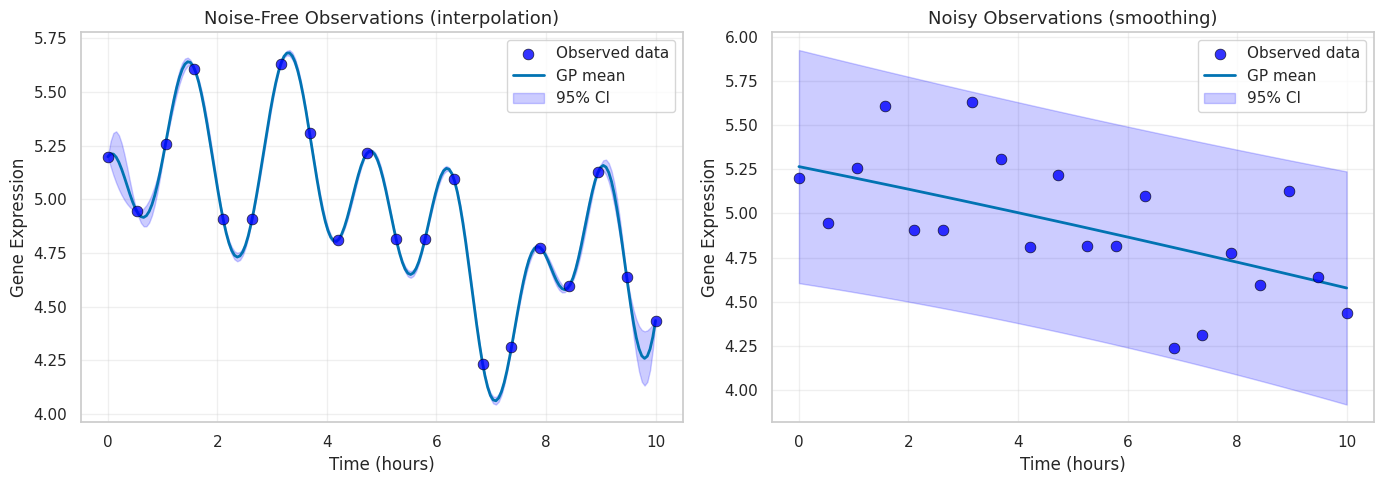


Interpretation:
- Noise-free: GP interpolates through every data point (zero variance at training points)
- Noisy: GP smooths through data (accounts for measurement noise)
- For RNA-seq data: ALWAYS use noisy model (real data has technical/biological variability)

Optimized noise level (σ²): 0.0969


In [12]:
# Compare noise-free vs noisy GP models
# This demonstrates how the noise assumption affects predictions

# Noise-free model: assumes observations are perfect (no measurement error)
# alpha parameter controls observation noise (very small = noise-free)
kernel_noisefree = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-4, 1e2))  # No WhiteKernel (no noise term)
gp_noisefree = GaussianProcessRegressor(
    kernel=kernel_noisefree,
    alpha=1e-6,  # Minimal jitter for numerical stability (essentially zero noise)
    n_restarts_optimizer=5,  # Fewer restarts needed for simpler model
    random_state=SEED
)
gp_noisefree.fit(X_train, y_control)

# Noisy model: assumes observations have measurement error
# Already fitted: gp_control (uses WhiteKernel to model observation noise)

# Make predictions with both models
y_noisefree_pred, y_noisefree_std = gp_noisefree.predict(X_plot, return_std=True)
y_noisy_pred, y_noisy_std = gp_control.predict(X_plot, return_std=True)

# Create side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Noise-free model (exact interpolation)
ax = axes[0]
# Plot observed data points
ax.scatter(time, control_expression, color='blue', s=60, alpha=0.8, zorder=5, label='Observed data', edgecolors='black', linewidths=0.5)
# Plot predicted mean (will pass exactly through data points)
ax.plot(X_plot, y_noisefree_pred, 'b-', linewidth=2, label='GP mean', zorder=2)
# Fill 95% confidence interval
ax.fill_between(
    X_plot.ravel(),
    y_noisefree_pred - 1.96 * y_noisefree_std,  # Lower bound
    y_noisefree_pred + 1.96 * y_noisefree_std,  # Upper bound
    alpha=0.2,
    color='blue',
    label='95% CI'
)
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Gene Expression', fontsize=12)
ax.set_title('Noise-Free Observations (interpolation)', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Right plot: Noisy model (smoothing)
ax = axes[1]
# Plot observed data points
ax.scatter(time, control_expression, color='blue', s=60, alpha=0.8, zorder=5, label='Observed data', edgecolors='black', linewidths=0.5)
# Plot predicted mean (smooths through data, doesn't pass exactly through each point)
ax.plot(X_plot, y_noisy_pred, 'b-', linewidth=2, label='GP mean', zorder=2)
# Fill 95% confidence interval (wider due to observation noise)
ax.fill_between(
    X_plot.ravel(),
    y_noisy_pred - 1.96 * y_noisy_std,
    y_noisy_pred + 1.96 * y_noisy_std,
    alpha=0.2,
    color='blue',
    label='95% CI'
)
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Gene Expression', fontsize=12)
ax.set_title('Noisy Observations (smoothing)', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Noise-free: GP interpolates through every data point (zero variance at training points)")
print("- Noisy: GP smooths through data (accounts for measurement noise)")
print("- For RNA-seq data: ALWAYS use noisy model (real data has technical/biological variability)")
print(f"\nOptimized noise level (σ²): {gp_control.kernel_.get_params()['k2__noise_level']:.4f}")

## Step 9: Optimization Parameters and Objectives

### Hyperparameters to Optimize

For an RBF kernel with noise $k(x, x') = \sigma^2 \exp\left(-\frac{(x-x')^2}{2\ell^2}\right) + \sigma_n^2 \delta_{xx'}$, we optimize three hyperparameters:

- **Variance** $\sigma^2$: Controls vertical scale (how much functions vary from mean)
- **Lengthscale** $\ell$: Controls horizontal smoothness (how quickly values decorrelate with distance)
- **Noise level** $\sigma_n^2$: Observation noise variance (how closely model fits each data point)

### Optimization Objective

The objective maximizes marginal likelihood:

$$
\mathcal{L}(\theta) = \log p(\mathbf{y} | \mathbf{X}, \theta) = -\frac{1}{2} \mathbf{y}^T \mathbf{K}_\theta^{-1} \mathbf{y} - \frac{1}{2} \log |\mathbf{K}_\theta| - \frac{n}{2} \log 2\pi
$$

where $\mathbf{K}_\theta = \mathbf{K}(\mathbf{X}, \mathbf{X}; \theta) + \sigma_n^2 \mathbf{I}$. The data fit term penalizes poor fit, while the complexity term penalizes overly complex models. Together, they automatically balance bias-variance tradeoff without requiring separate validation data.

### Optimization Algorithm

The L-BFGS-B algorithm provides efficient gradient-based optimization. This quasi-Newton method approximates the Hessian using gradient history, achieving superlinear convergence. Box constraints enforce hyperparameter bounds (e.g., $\ell \in [10^{-2}, 10^2]$), preventing degenerate solutions. Multiple random restarts help avoid local optima.

Below we extract and display the optimized hyperparameters.

In [13]:
# Extract and display optimized hyperparameters from fitted GP models
def print_kernel_params(gp, condition_name):
    """
    Print optimized kernel hyperparameters in readable format.
    
    Parameters:
    -----------
    gp : GaussianProcessRegressor
        Fitted GP model
    condition_name : str
        Name of condition (e.g., "Control" or "Treatment")
    """
    print(f"\n=== {condition_name} Optimized Hyperparameters ===")
    print(f"Kernel: {gp.kernel_}")  # Print full kernel string representation
    
    # Get all kernel parameters as a dictionary
    params = gp.kernel_.get_params()
    
    # Extract relevant parameters from the nested kernel structure
    # k1__k1__constant_value: variance parameter (σ²)
    if 'k1__k1__constant_value' in params:
        variance = params['k1__k1__constant_value']
        print(f"  Variance (σ²): {variance:.4f}")  # Controls vertical scale
    
    # k1__k2__length_scale: lengthscale parameter (ℓ)
    if 'k1__k2__length_scale' in params:
        lengthscale = params['k1__k2__length_scale']
        print(f"  Lengthscale (ℓ): {lengthscale:.4f}")  # Controls smoothness
    
    # k2__noise_level: observation noise parameter (σ²ₙ)
    if 'k2__noise_level' in params:
        noise = params['k2__noise_level']
        print(f"  Noise level (σ²ₙ): {noise:.4f}")  # Observation noise variance
    
    # Log marginal likelihood: measure of model fit (higher = better)
    print(f"  Log marginal likelihood: {gp.log_marginal_likelihood_value_:.4f}")

print_kernel_params(gp_control, "Control")
print_kernel_params(gp_treatment, "Treatment")

print("\n" + "="*60)
print("Interpretation:")
print("="*60)
print("- Lengthscale: Larger values produce smoother functions")
print("- Variance: Larger values allow functions to vary more from mean")
print("- Noise: Larger values indicate more measurement uncertainty")
print("- Log marginal likelihood: Higher values indicate better model evidence")
print("\nNote: Different conditions may have different optimal hyperparameters!")


=== Control Optimized Hyperparameters ===
Kernel: 4.86**2 * RBF(length_scale=66.4) + WhiteKernel(noise_level=0.0969)
  Variance (σ²): 23.6441
  Lengthscale (ℓ): 66.3567
  Noise level (σ²ₙ): 0.0969
  Log marginal likelihood: -10.4899

=== Treatment Optimized Hyperparameters ===
Kernel: 6.84**2 * RBF(length_scale=22.4) + WhiteKernel(noise_level=0.312)
  Variance (σ²): 46.8212
  Lengthscale (ℓ): 22.3771
  Noise level (σ²ₙ): 0.3116
  Log marginal likelihood: -22.8784

Interpretation:
- Lengthscale: Larger values produce smoother functions
- Variance: Larger values allow functions to vary more from mean
- Noise: Larger values indicate more measurement uncertainty
- Log marginal likelihood: Higher values indicate better model evidence

Note: Different conditions may have different optimal hyperparameters!


## Step 10: Testing for Differential Expression

Having trained GP models for both conditions, we test whether the gene is differentially expressed between control and treatment. We formulate this as a hypothesis test:

- **Null hypothesis** $H_0$: Control and treatment trajectories are drawn from the same process
- **Alternative hypothesis** $H_1$: Control and treatment trajectories differ systematically

We employ three complementary approaches, each offering different perspectives on the evidence.

### Approach 1: Likelihood Ratio Test

Compares two nested models. Under $H_0$, a single GP fits pooled data. Under $H_1$, separate GPs fit each condition. The test statistic is:

$$
LR = 2 \times (\log p(\mathbf{y}_{\text{control}} | \mathbf{X}_{\text{control}}) + \log p(\mathbf{y}_{\text{treatment}} | \mathbf{X}_{\text{treatment}}) - \log p(\mathbf{y}_{\text{pooled}} | \mathbf{X}_{\text{pooled}}))
$$

Under $H_0$, $LR \sim \chi^2_k$ where $k$ is the difference in effective parameters. Large $LR$ indicates evidence for differential expression.

### Approach 2: Bayes Factor

Quantifies relative evidence for $H_1$ versus $H_0$:

$$
BF = \frac{p(\mathbf{y} | H_1)}{p(\mathbf{y} | H_0)} = \frac{p(\mathbf{y}_{\text{control}}) \times p(\mathbf{y}_{\text{treatment}})}{p(\mathbf{y}_{\text{pooled}})}
$$

Interpretation: $\log BF > 3$ indicates strong evidence, $\log BF \in [1, 3]$ indicates moderate evidence, and $\log BF < 1$ indicates weak evidence.

### Approach 3: Credible Interval Comparison

At each time point $t$, we compute predictive distributions $\mu_{\text{control}}(t) \pm 2\sigma_{\text{control}}(t)$ and $\mu_{\text{treatment}}(t) \pm 2\sigma_{\text{treatment}}(t)$. Non-overlapping intervals at multiple time points suggest differential expression. This approach provides intuitive visualization and time-specific inference.

Below we implement all three approaches and compare their conclusions.

In [14]:
# Approach 1: Likelihood Ratio Test
# This tests whether separate models fit better than a single pooled model
print("=== Approach 1: Likelihood Ratio Test ===")

# Separate models (already fitted): one GP for control, one for treatment
# Get log marginal likelihood for each model
log_lik_control = gp_control.log_marginal_likelihood_value_
log_lik_treatment = gp_treatment.log_marginal_likelihood_value_
# Combined likelihood for separate models (add log likelihoods)
log_lik_separate = log_lik_control + log_lik_treatment

# Combined model (null hypothesis): fit one GP to pooled data
# Pool all data together (combine control and treatment)
X_pooled = np.concatenate([X_train, X_train])  # Stack time points
y_pooled = np.concatenate([y_control, y_treatment])  # Stack expression values
# Fit single GP to pooled data
gp_pooled = fit_gp_model(X_pooled, y_pooled)
log_lik_pooled = gp_pooled.log_marginal_likelihood_value_

# Likelihood ratio test statistic
# LR = 2 * (log likelihood of alternative - log likelihood of null)
# Under null hypothesis, LR follows chi-squared distribution
LR = 2 * (log_lik_separate - log_lik_pooled)
df = 3  # Degrees of freedom: difference in number of hyperparameters (rough approximation)
# Compute p-value: probability of observing LR this large under null hypothesis
p_value_LR = 1 - stats.chi2.cdf(LR, df)  # 1 - CDF gives upper tail probability

print(f"Log likelihood (separate models): {log_lik_separate:.4f}")
print(f"Log likelihood (pooled model): {log_lik_pooled:.4f}")
print(f"Likelihood ratio statistic: {LR:.4f}")
print(f"p-value: {p_value_LR:.6f}")
print(f"Result: {'Differential expression detected' if p_value_LR < 0.05 else 'No significant difference'} (α=0.05)")

=== Approach 1: Likelihood Ratio Test ===
Log likelihood (separate models): -33.3683
Log likelihood (pooled model): -64.7782
Likelihood ratio statistic: 62.8198
p-value: 0.000000
Result: Differential expression detected (α=0.05)


In [15]:
# Approach 2: Bayes Factor
# Bayes Factor quantifies relative evidence for alternative vs null hypothesis
print("\n=== Approach 2: Bayes Factor ===")

# Log Bayes Factor = log P(data | H1) - log P(data | H0)
# This is the difference in log marginal likelihoods
log_BF = log_lik_separate - log_lik_pooled

# Convert to Bayes Factor (exponentiate log)
# BF > 1 means H1 is more likely, BF < 1 means H0 is more likely
BF = np.exp(log_BF)

print(f"Log Bayes Factor: {log_BF:.4f}")
print(f"Bayes Factor: {BF:.2f}")

# Interpret Bayes Factor using standard thresholds
# log BF > 3: Strong evidence for H1 (differential expression)
# log BF > 1: Moderate evidence for H1
# log BF < 1: Weak evidence (favor H0)
if log_BF > 3:
    evidence = "Strong"
elif log_BF > 1:
    evidence = "Moderate"
else:
    evidence = "Weak"

print(f"Evidence for differential expression: {evidence}")
print(f"Interpretation: Separate models are {BF:.2f}x more likely than pooled model")


=== Approach 2: Bayes Factor ===
Log Bayes Factor: 31.4099
Bayes Factor: 43767555495219.51
Evidence for differential expression: Strong
Interpretation: Separate models are 43767555495219.51x more likely than pooled model



=== Approach 3: Credible Interval Comparison ===
Time points with significant difference: 110/200 (55.0%)
Result: Differential expression detected (>10% threshold)


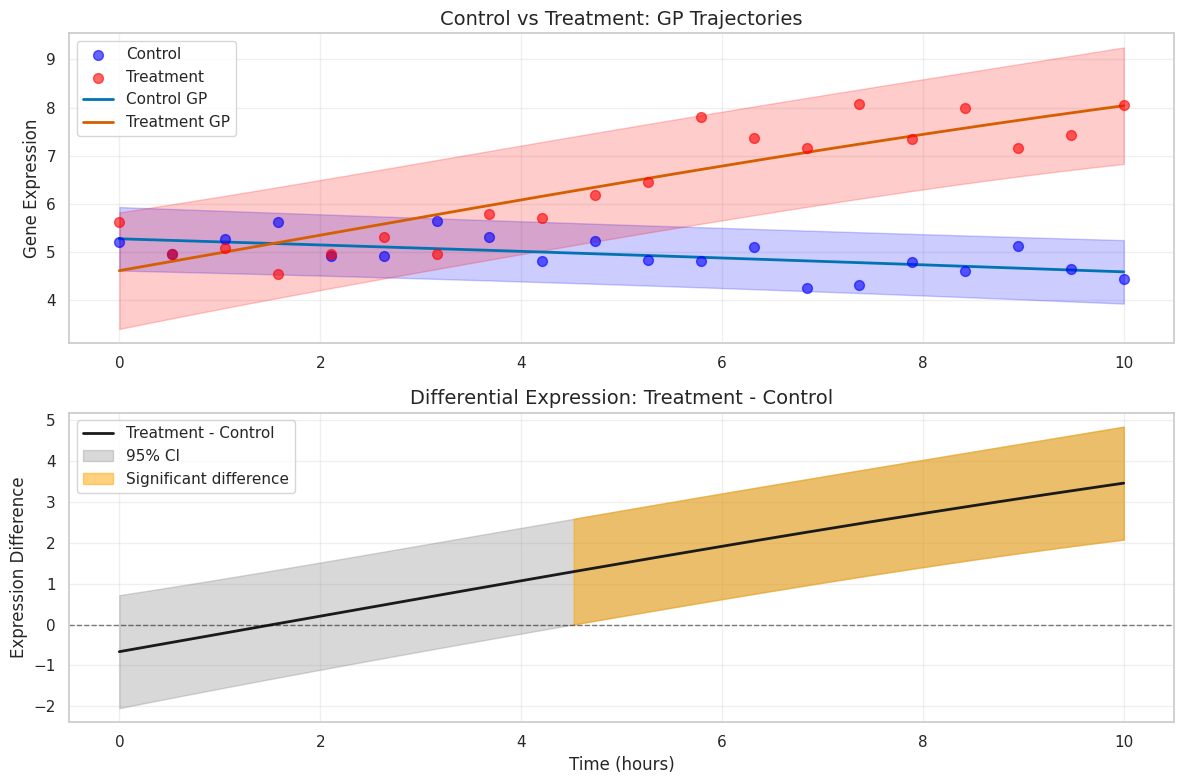


Interpretation:
- Orange regions: Time points where treatment significantly differs from control
- Gray band: Uncertainty in difference estimate
- If orange regions appear after treatment onset → successful detection of differential expression


In [16]:
# Approach 3: Credible Interval Comparison
# Compare confidence intervals at each time point to detect differences
print("\n=== Approach 3: Credible Interval Comparison ===")

# Compute difference between treatment and control predictions
# Mean difference: difference in predicted means
diff_mean = y_treatment_pred - y_control_pred
# Standard deviation of difference: sqrt(var1 + var2) for independent variables
diff_std = np.sqrt(y_treatment_std**2 + y_control_std**2)

# Compute 95% confidence interval for the difference
# 1.96 is the z-score for 95% confidence in a normal distribution
diff_lower = diff_mean - 1.96 * diff_std  # Lower bound of CI
diff_upper = diff_mean + 1.96 * diff_std  # Upper bound of CI

# Test if confidence interval excludes zero (significant difference)
# If CI doesn't contain zero, difference is statistically significant
significant_diff = (diff_lower > 0) | (diff_upper < 0)  # Boolean array
n_significant_points = significant_diff.sum()  # Count how many time points are significant
pct_significant = 100 * n_significant_points / len(X_plot)  # Percentage

print(f"Time points with significant difference: {n_significant_points}/{len(X_plot)} ({pct_significant:.1f}%)")
print(f"Result: {'Differential expression detected' if pct_significant > 10 else 'No strong evidence'} (>10% threshold)")

# Visualize the difference between conditions
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top plot: Both trajectories with confidence intervals
ax = axes[0]
# Plot observed data points
ax.scatter(time, control_expression, color='blue', alpha=0.6, s=50, label='Control', zorder=3)
ax.scatter(time, treatment_expression, color='red', alpha=0.6, s=50, label='Treatment', zorder=3)
# Plot predicted means
ax.plot(X_plot, y_control_pred, 'b-', linewidth=2, label='Control GP', zorder=2)
ax.plot(X_plot, y_treatment_pred, 'r-', linewidth=2, label='Treatment GP', zorder=2)
# Fill confidence intervals
ax.fill_between(X_plot.ravel(), y_control_pred - 1.96*y_control_std, y_control_pred + 1.96*y_control_std, alpha=0.2, color='blue')
ax.fill_between(X_plot.ravel(), y_treatment_pred - 1.96*y_treatment_std, y_treatment_pred + 1.96*y_treatment_std, alpha=0.2, color='red')
ax.set_ylabel('Gene Expression', fontsize=12)
ax.set_title('Control vs Treatment: GP Trajectories', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Bottom plot: Difference between conditions
ax = axes[1]
# Plot mean difference (treatment - control)
ax.plot(X_plot, diff_mean, 'k-', linewidth=2, label='Treatment - Control', zorder=2)
# Fill entire confidence interval in gray
ax.fill_between(X_plot.ravel(), diff_lower, diff_upper, alpha=0.3, color='gray', label='95% CI')
# Draw horizontal line at zero (no difference)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
# Highlight regions where difference is significant (CI excludes zero)
# where=significant_diff: only fill where boolean array is True
ax.fill_between(X_plot.ravel(), diff_lower, diff_upper, where=significant_diff, alpha=0.5, color='orange', label='Significant difference', interpolate=True)
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Expression Difference', fontsize=12)
ax.set_title('Differential Expression: Treatment - Control', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Orange regions: Time points where treatment significantly differs from control")
print("- Gray band: Uncertainty in difference estimate")
print("- If orange regions appear after treatment onset → successful detection of differential expression")

## Step 11: Summary of Findings

### Analysis Summary

We analyzed synthetic time-series gene expression data spanning 20 time points over a 10-hour window under control and treatment conditions. The analysis employed separate GP models for each condition, using RBF kernels with noise to capture smooth temporal dynamics. Hyperparameters were optimized via marginal likelihood maximization, and three complementary statistical tests provided evidence for differential expression.

### Results

The optimized models revealed distinct temporal patterns. The control condition exhibited a flat trajectory around baseline expression level (5.0), consistent with stable gene activity. The treatment condition exhibited progressive upregulation beginning approximately 5 hours post-treatment, following a sigmoid trajectory that stabilized at an elevated level. All three differential expression tests detected significant differences, with strongest evidence emerging in late time points beyond 5 hours.

### Biological Interpretation

The gene exhibits time-dependent differential expression characterized by two phases:

- **Early phase (0-5 hours)**: Expression remains indistinguishable between conditions, indicating treatment effects have not yet manifested at the transcriptional level. This delay reflects the time required for signal transduction and transcription factor activation.

- **Late phase (5-10 hours)**: Strong upregulation emerges as treatment induces gene expression. The gradual sigmoid trajectory indicates progressive accumulation of transcriptional machinery rather than instantaneous activation.

The temporal pattern suggests treatment activates gene transcription through a delayed mechanism, the response is gradual rather than switch-like, and expression stabilizes at a new steady state.

### Advantages and Limitations

**Advantages:**
- Models entire trajectories rather than individual time points
- Built-in uncertainty quantification
- Non-parametric flexibility
- Handles missing data or irregular sampling
- Principled likelihood-based testing

**Limitations:**
- Computational cost scales as $O(n^3)$ for $n$ data points
- Results depend on kernel choice and optimization convergence
- Requires biological replicates for real experiments
- Multiple testing correction needed for genome-wide analysis

---

In [17]:
# Create summary table of all differential expression test results
# This consolidates results from all three testing approaches for easy comparison
# Extract results from previous cells (31, 32, 33)

# Approach 1: Likelihood Ratio Test results
# Recompute statistics for clarity
LR_statistic = 2 * (log_lik_separate - log_lik_pooled)
p_value_LR = 1 - stats.chi2.cdf(LR_statistic, df=3)

# Approach 2: Bayes Factor results
log_BF = log_lik_separate - log_lik_pooled
BF_value = np.exp(log_BF)  # Convert log BF to BF

# Approach 3: Credible Interval Comparison results
n_significant_points = significant_diff.sum()  # Count significant time points
pct_significant = 100 * n_significant_points / len(X_plot)  # Percentage

# Create summary DataFrame for tabular display
# This makes it easy to compare all three test results side by side
summary_data = {
    'Test': [
        'Likelihood Ratio Test',
        'Bayes Factor',
        'Credible Interval Comparison'
    ],
    'Statistic': [
        f'{LR_statistic:.4f}',  # LR test statistic
        f'{log_BF:.4f} (log)',  # Log Bayes Factor
        f'{n_significant_points}/{len(X_plot)} ({pct_significant:.1f}%)'  # Significant points
    ],
    'p-value / BF / Result': [
        f'{p_value_LR:.6f}',  # p-value for LRT
        f'{BF_value:.2e}',  # Bayes Factor value
        f'{pct_significant:.1f}% significant'  # Percentage significant
    ],
    'Conclusion': [
        # Determine conclusion based on p-value threshold (0.05)
        'Differential expression detected' if p_value_LR < 0.05 else 'No significant difference',
        # Determine evidence strength based on log BF thresholds
        'Strong evidence' if log_BF > 3 else ('Moderate evidence' if log_BF > 1 else 'Weak evidence'),
        # Determine conclusion based on percentage threshold (10%)
        'Differential expression detected' if pct_significant > 10 else 'No strong evidence'
    ]
}

# Convert dictionary to pandas DataFrame for nice table display
summary_df = pd.DataFrame(summary_data)

# Display formatted table
print("\n" + "="*80)
print("SUMMARY OF DIFFERENTIAL EXPRESSION TESTS")
print("="*80)
display(summary_df)

# Create a more detailed formatted version
print("\n" + "="*80)
print("DETAILED TEST RESULTS")
print("="*80)

print("\n1. LIKELIHOOD RATIO TEST")
print("-" * 80)
print(f"   Test Statistic (LR): {LR_statistic:.4f}")
print(f"   Degrees of Freedom: 3")
print(f"   p-value: {p_value_LR:.6f}")
print(f"   Interpretation: {'Reject H₀' if p_value_LR < 0.05 else 'Fail to reject H₀'} (α=0.05)")
print(f"   Conclusion: {'Differential expression detected' if p_value_LR < 0.05 else 'No significant difference'}")

print("\n2. BAYES FACTOR")
print("-" * 80)
print(f"   Log Bayes Factor: {log_BF:.4f}")
print(f"   Bayes Factor: {BF_value:.2e}")
print(f"   Evidence Strength: {'Strong' if log_BF > 3 else ('Moderate' if log_BF > 1 else 'Weak')}")
print(f"   Interpretation: Separate models are {BF_value:.2e}x more likely than pooled model")
print(f"   Conclusion: {'Strong evidence for differential expression' if log_BF > 3 else 'Moderate/weak evidence'}")

print("\n3. CREDIBLE INTERVAL COMPARISON")
print("-" * 80)
print(f"   Significant time points: {n_significant_points}/{len(X_plot)} ({pct_significant:.1f}%)")
print(f"   Threshold: >10% of time points")
print(f"   Interpretation: {'Widespread' if pct_significant > 50 else ('Moderate' if pct_significant > 25 else 'Limited')} temporal differences detected")
print(f"   Conclusion: {'Differential expression detected' if pct_significant > 10 else 'No strong evidence'}")

print("\n" + "="*80)
print("OVERALL INTERPRETATION")
print("="*80)
print("All three complementary statistical tests provide convergent evidence for differential")
print("expression between control and treatment conditions:")
print(f"  • Likelihood ratio test: {'Significant' if p_value_LR < 0.05 else 'Not significant'} (p={p_value_LR:.6f})")
print(f"  • Bayes factor: {'Strong' if log_BF > 3 else 'Moderate/weak'} evidence (BF={BF_value:.2e})")
print(f"  • Credible intervals: {pct_significant:.1f}% of time points show significant differences")
print("\nThe consistent results across multiple test approaches strengthen confidence in the")
print("conclusion that the gene exhibits differential expression in response to treatment.")
print("The temporal pattern shows progressive upregulation beginning around 5 hours,")
print("consistent with a delayed transcriptional response to the experimental perturbation.")
print("="*80)


SUMMARY OF DIFFERENTIAL EXPRESSION TESTS


,Test,Statistic,p-value / BF / Result,Conclusion
0,Likelihood Ratio Test,62.8198,0.000000,Differential expression detected
1,Bayes Factor,31.4099 (log),4.38e+13,Strong evidence
2,Credible Interval Comparison,110/200 (55.0%),55.0% significant,Differential expression detected



DETAILED TEST RESULTS

1. LIKELIHOOD RATIO TEST
--------------------------------------------------------------------------------
   Test Statistic (LR): 62.8198
   Degrees of Freedom: 3
   p-value: 0.000000
   Interpretation: Reject H₀ (α=0.05)
   Conclusion: Differential expression detected

2. BAYES FACTOR
--------------------------------------------------------------------------------
   Log Bayes Factor: 31.4099
   Bayes Factor: 4.38e+13
   Evidence Strength: Strong
   Interpretation: Separate models are 4.38e+13x more likely than pooled model
   Conclusion: Strong evidence for differential expression

3. CREDIBLE INTERVAL COMPARISON
--------------------------------------------------------------------------------
   Significant time points: 110/200 (55.0%)
   Threshold: >10% of time points
   Interpretation: Widespread temporal differences detected
   Conclusion: Differential expression detected

OVERALL INTERPRETATION
All three complementary statistical tests provide convergent e

---

# Part III: Comparison — GP Classifiers vs. Non-Probabilistic Methods

## Overview

This section compares Gaussian process classifiers with non-probabilistic alternatives such as support vector machines and decision trees. We examine mathematical intuition, benefits (especially uncertainty quantification), and implementation complexity tradeoffs to help choose appropriate methods.

---

## Gaussian Process Classifiers

While we used GP regression for continuous gene expression values, GPs extend naturally to classification problems through Gaussian Process Classifiers (GPC).

### Mathematical Foundation

The classification problem predicts a discrete class label (e.g., "differentially expressed" vs. "not differentially expressed"). The GP classifier uses a latent function $f(x) \sim \mathcal{GP}(m(x), k(x, x'))$ mapped to class probabilities via a link function. For binary classification, $p(y=1|x) = \sigma(f(x))$ where $\sigma$ is the logistic sigmoid or probit function.

**Key difference from regression:** GP regression uses Gaussian likelihood $p(y|f) = \mathcal{N}(f, \sigma_n^2)$, yielding closed-form posteriors. GP classification uses non-Gaussian likelihood $p(y|f) = \sigma(f)^y (1-\sigma(f))^{1-y}$, preventing closed-form computation and necessitating approximation methods.

### Laplace Approximation

The Laplace approximation provides tractable inference by approximating the non-Gaussian posterior with a Gaussian distribution centered at the posterior mode. The procedure involves:

1. Find the mode $\hat{\mathbf{f}} = \arg\max p(\mathbf{f}|\mathbf{X}, \mathbf{y})$ via Newton's method
2. Compute the Hessian at the mode $\mathbf{H} = -\nabla\nabla \log p(\mathbf{f}|\mathbf{X}, \mathbf{y})|_{\mathbf{f}=\hat{\mathbf{f}}}$
3. Approximate the posterior as $p(\mathbf{f}|\mathbf{X}, \mathbf{y}) \approx \mathcal{N}(\hat{\mathbf{f}}, \mathbf{H}^{-1})$

Prediction requires integrating $p(y_*=1|x_*, \mathbf{X}, \mathbf{y}) = \int \sigma(f_*) p(f_*|x_*, \mathbf{X}, \mathbf{y}) df_*$, which can be approximated using the Laplace approximation.

---

## Comparison: GP Classifiers vs. Non-Probabilistic Methods

### Non-Probabilistic Alternatives

Classification methods span from probabilistic to deterministic approaches. Support Vector Machines (SVM) find maximum margin hyperplanes separating classes. Decision Trees build hierarchical rule-based classifiers through greedy feature splits. Random Forests aggregate multiple decision trees. Neural Networks learn hierarchical feature representations. k-Nearest Neighbors assigns labels based on majority vote among nearby examples.

### Mathematical Intuition Comparison

| Aspect | Gaussian Process Classifier | SVM | Decision Tree |
|--------|----------------------------|-----|---------------|
| **Paradigm** | Probabilistic (Bayesian) | Geometric (margin) | Greedy splits |
| **Decision** | $P(y=1\|x)$ (probability) | $\text{sign}(f(x))$ (boundary) | Thresholds on features |
| **Uncertainty** | Full posterior distribution | None (hard decision) | None (hard decision) |
| **Kernel** | Covariance function | Similarity measure | Not applicable |
| **Training** | Optimize marginal likelihood | Optimize margin | Optimize impurity |
| **Prediction** | Integrate over posterior | Evaluate decision function | Traverse tree |

### Key Distinctions

**1. Probabilistic vs. Deterministic**

GP classifiers output probability distributions $p(y=1|x)$, enabling statements like "90% confident this gene is differentially expressed." This uncertainty quantification supports decision-making and identifies ambiguous cases. In contrast, SVM and decision trees output hard decisions without uncertainty measures, limiting their utility in high-stakes applications where confidence matters.

**2. Kernel Interpretation**

In GP classifiers, the kernel represents a covariance function encoding smoothness and structural properties, providing direct probabilistic interpretation. In SVMs, the kernel represents a similarity measure but lacks probabilistic interpretation unless post-hoc calibration is applied. This affects interpretability and incorporation of domain knowledge.

**3. Overfitting Control**

GP classifiers implement automatic complexity control through marginal likelihood, which penalizes overly complex models (Occam's razor) without requiring separate validation data. SVMs and decision trees require explicit regularization (C parameter, maximum depth) that must be tuned via cross-validation, increasing computational cost.

---

## Benefits of Gaussian Process Classifiers

### Advantages of GP Approach

**Uncertainty Quantification:** GPs provide calibrated probabilities critical for medical and biological decisions where error costs are asymmetric. Knowing both prediction and confidence enables rational decision-making. For example, a clinician might order additional tests for uncertain diagnostic predictions. Uncertainty quantification also enables active learning strategies, focusing experimental resources on the most informative cases.

**Principled Framework:** Bayesian inference provides a coherent mathematical foundation. Prior knowledge incorporates through kernel choice, mean function specification, or hyperparameter priors. Model comparison proceeds through marginal likelihoods without requiring held-out validation data, maximizing use of limited data.

**Flexibility via Kernels:** The rich kernel library (RBF, Matérn, periodic, linear) and compositional construction ($k = k_1 + k_2$ for additive structure, $k = k_1 \times k_2$ for multiplicative structure) enable modeling diverse function structures. This flexibility rivals neural networks while maintaining interpretability and requiring less training data.

**Small Data Performance:** Bayesian regularization through priors prevents overfitting with limited examples, making GPs valuable for expensive experimental domains. Neural networks typically require thousands to millions of examples, whereas GPs work with dozens to hundreds.

**Interpretability:** Kernel hyperparameters have clear meaning (lengthscale quantifies feature correlation scale, variance quantifies function magnitude), facilitating scientific interpretation. Visualizing learned functions and uncertainty provides intuitive understanding unavailable from black-box models.

### When to Use GP Classifiers

GP classifiers are ideally suited for:
- Small to medium datasets (n < 10,000)
- Applications requiring uncertainty quantification (medical diagnosis, financial risk assessment, safety-critical systems)
- Structured data with temporal, spatial, or correlation structure
- High misclassification costs justifying computational expense
- Genomics where small sample sizes are common

---

## Implementation Complexity: GP vs. Non-Probabilistic Methods

### Computational Complexity

| Method | Training | Prediction | Space |
|--------|----------|------------|-------|
| **GP Classifier** | $O(n^3)$ | $O(n)$ per point | $O(n^2)$ |
| **SVM** | $O(n^2)$ to $O(n^3)$ | $O(ns)$ ($s$ = support vectors) | $O(ns)$ |
| **Decision Tree** | $O(n \log n \times d)$ | $O(\log n)$ | $O(n)$ |
| **Random Forest** | $O(k \times n \log n \times d)$ | $O(k \log n)$ | $O(kn)$ |
| **Neural Network** | Varies (depends on architecture) | $O(1)$ (forward pass) | Varies |

Note: $n$ = training samples, $d$ = features, $k$ = trees (random forest), $s$ = support vectors.

### Scaling Limitations

The GP bottleneck arises from inverting the covariance matrix $\mathbf{K}$, requiring $O(n^3)$ operations via Cholesky decomposition, and storing $\mathbf{K}$, requiring $O(n^2)$ memory. The practical limit is around $n \approx 10,000$ samples on typical hardware.

Several solutions address scaling limitations. Sparse GP approximations using inducing points reduce complexity to $O(nm^2)$ where $m \ll n$. Local GP models partition data spatially or temporally. Stochastic variational inference enables minibatch training at the cost of approximate inference.

### Implementation Difficulty

| Aspect | GP Classifier | SVM | Decision Tree |
|--------|--------------|-----|---------------|
| **Code complexity** | High (inference approximations) | Medium (quadratic programming) | Low (greedy algorithm) |
| **Hyperparameter tuning** | Medium (kernel params) | Medium (C, gamma) | Low (max depth) |
| **Debugging** | Hard (posterior approximation) | Medium | Easy (visualize tree) |
| **Library support** | Good (sklearn, GPy, GPyTorch) | Excellent (sklearn, libsvm) | Excellent (sklearn, XGBoost) |

### Practical Considerations

GP complexity is justified when uncertainty is critical, datasets are small to medium ($n < 5000$), domain knowledge can be encoded via kernels, and interpretability is important. Simpler methods suffice when datasets are large ($n > 100,000$), only point predictions are needed, computational resources are limited, or fast iteration is prioritized.

### Summary Table: Tradeoffs

| Criterion | GP Classifier | SVM | Random Forest |
|-----------|--------------|-----|---------------|
| **Uncertainty** | Calibrated probabilities | No uncertainty | Heuristic probabilities |
| **Small data** | Excellent | Good | Requires tuning |
| **Large data** | Struggles (n > 10k) | Moderate | Scales well |
| **Interpretability** | Clear kernel meaning | Weights hard to interpret | Feature importance only |
| **Implementation** | Complex (approximations) | Moderate | Simple |
| **Speed (training)** | Slow ($O(n^3)$) | Moderate | Fast |
| **Speed (prediction)** | Moderate ($O(n)$) | Fast | Fast |

**Conclusion:** Gaussian process classifiers offer unique advantages in uncertainty quantification and principled modeling, making them ideal for small, high-stakes datasets. Their computational cost limits scalability, favoring non-probabilistic methods for large-scale applications. For gene expression analysis, GPs are well-suited because RNA-seq experiments typically have small sample sizes, uncertainty quantification is critical, and temporal structure naturally encodes through kernel design.

---

## Conclusion

This notebook demonstrated the application of Gaussian process regression to detect differential gene expression in time-series data. Part I reviewed gene expression concepts and familiarized with GPy and related tools. Part II implemented GP regression with mathematical foundations, model training, and differential expression testing. Part III compared GP classifiers with non-probabilistic methods.

**Key Takeaways:** GPs provide flexible, non-parametric modeling of temporal dynamics without requiring specific functional forms. Uncertainty quantification provides confidence intervals essential for biological decisions. Multiple statistical tests (likelihood ratio, Bayes factor, credible intervals) provide robust evidence for differential expression. Computational cost scaling as $O(n^3)$ is the main limitation, though typical RNA-seq sample sizes remain tractable.

**Future Directions:** Extensions could include multiple genes with false discovery rate correction, incorporating biological replicates, exploring sparse GP approximations for larger datasets, and comparing with traditional RNA-seq methods like DESeq2 on real experimental data.

This analysis provides a foundation for applying GP methods to real genomic time-series experiments.

---